# CONUS Surface Temperature Station Locations
### NCEP ADP Global Surface Obs — GDEX d461000 (little_r format)

Identifies CONUS stations with **≥ 90% temporal coverage** across 2016–2026
using seasonal sampling (Jan / Apr / Jul / Oct, 15th of each month, 00z cycle).

Data path: `/glade/campaign/collections/rda/data/d461000/little_r/{YYYY}/SURFACE_OBS:YYYYMMDDH`

Each station record is 4 lines:
- **Line 1**: lat, lon, station ID, name, elevation, timestamp, header values
- **Line 2**: pressure, elevation, temperature (K), dewpoint, wind speed, wind dir, ...
- **Line 3**: end-of-data marker (-777777)
- **Line 4**: record count

Missing values are encoded as `-888888`.

**Outputs:**
- `conus_qualifying_stations.shp` — one point per qualifying station
- `conus_county_station_density.gpkg` — county polygons with station count and density

**Estimated run time:** 5–15 min  
**Estimated memory:** < 1 GB


In [19]:
import datetime
import collections
import logging
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from tqdm.notebook import tqdm
import duckdb
import os
import pandas as pd
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
)
log = logging.getLogger(__name__)

In [20]:
def fix_init(init):
    init_int = int(str(init).lstrip("0") or "0")
    assert init_int in (0, 12), f"Invalid init '{init}' (must be 00z or 12z)"
    return {0: "0000", 12: "1200"}[init_int]

In [21]:
DATA_DIR   = "/glade/campaign/collections/rda/data/d461000/little_r"
SCRATCH = "/glade/derecho/scratch/dcalhoun"
OUTPUT_DIR = os.path.join(SCRATCH, "station_locations")
IFS_COUNTY_PATH  = os.path.join(SCRATCH, "aggregated/ifs_fc_bias_anom_2t_county.parquet")
AIFS_COUNTY_PATH = os.path.join(SCRATCH, "aggregated/aifs_fc_bias_anom_2t_county.parquet")

OUT_SHP    = os.path.join(OUTPUT_DIR, "conus_qualifying_stations.shp")
OUT_COUNTY = os.path.join(OUTPUT_DIR, "conus_county_station_density.gpkg")

# Census TIGER county shapefile
# Download from: https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
COUNTY_SHP = os.path.join(SCRATCH, "census", "shapefiles", "nhgis0003_shapefile_tl2024_us_county_2024/US_county_2024.shp")
os.makedirs(OUTPUT_DIR, exist_ok=True)

START_YEAR = 2016
END_YEAR   = 2026
LEADS = [12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 168, 240]

# One month per season, 00z cycle on the 15th
SAMPLE_MONTHS = list(range(1, 13))
SAMPLE_DAY    = 15

COVERAGE_THRESHOLD = 0.90

# CONUS bounding box
LAT_MIN, LAT_MAX =  24.0,  50.0
LON_MIN, LON_MAX = -125.0, -66.0

MISSING = -888888.0

CONUS_FIPS = {f"{i:02d}" for i in range(1, 57)
              if i not in (2, 15, 60, 64, 66, 69, 72, 74, 78)}

print("Configuration loaded.")
print(f"  Data directory   : {DATA_DIR}")
print(f"  Output directory : {OUTPUT_DIR}")
print(f"  Sample months    : {SAMPLE_MONTHS}")
print(f"  Coverage thresh  : {COVERAGE_THRESHOLD:.0%}")


Configuration loaded.
  Data directory   : /glade/campaign/collections/rda/data/d461000/little_r
  Output directory : /glade/derecho/scratch/dcalhoun/station_locations
  Sample months    : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Coverage thresh  : 90%


In [22]:
def build_sample_dates():
    today = datetime.date.today()
    dates = []
    for year in range(START_YEAR, END_YEAR + 1):
        for month in SAMPLE_MONTHS:
            d = datetime.date(year, month, SAMPLE_DAY)
            if d <= today:
                dates.append((year, month))
    return dates

sample_dates = build_sample_dates()
print(f"{len(sample_dates)} sample months identified.")
print("First:", sample_dates[:4])
print("Last :", sample_dates[-4:])


123 sample months identified.
First: [(2016, 1), (2016, 2), (2016, 3), (2016, 4)]
Last : [(2025, 12), (2026, 1), (2026, 2), (2026, 3)]


In [23]:
def find_file_for_date(year, month, day):
    """
    Return path to SURFACE_OBS:YYYYMMDD00 for the given date.
    Tries exact date first, then ±3 days.
    """
    for delta in range(0, 4):
        for sign in (0, -1, 1):
            d = datetime.date(year, month, day) + datetime.timedelta(days=sign * delta)
            if d.year != year:
                continue
            candidate = os.path.join(
                DATA_DIR,
                str(year),
                f"SURFACE_OBS:{d.strftime('%Y%m%d')}00"
            )
            if os.path.exists(candidate):
                return candidate
    return None


def parse_little_r(filepath):
    """
    Parse a little_r SURFACE_OBS file.
    Returns dict: station_id -> {"lat", "lon", "elevation", "name", "temp_k"}
    Only CONUS stations with a valid temperature are returned.

    Line 1 fixed-width layout:
      0:20   lat
      20:40  lon
      40:46  station ID
      46:95  name
      200:213 elevation (m)

    Line 2 fixed-width layout (13 value + 7 QC = 20 chars per field):
      0:13   pressure
      20:33  elevation
      40:53  temperature (K)
      60:73  dewpoint
      80:93  wind speed
      100:113 wind direction
    """
    found = {}
    try:
        with open(filepath, "r", encoding="latin-1") as f:
            lines = f.readlines()
    except Exception as exc:
        log.error("Cannot read %s: %s", filepath, exc)
        return found

    i = 0
    while i < len(lines) - 2:
        line1 = lines[i]

        if len(line1) < 40:
            i += 1
            continue

        try:
            lat = float(line1[0:20])
            lon = float(line1[20:40])
        except ValueError:
            i += 1
            continue

        if not (LAT_MIN <= lat <= LAT_MAX and LON_MIN <= lon <= LON_MAX):
            i += 4
            continue

        station_id = line1[40:46].strip()
        name       = line1[46:95].strip()

        try:
            elev = float(line1[200:213].strip())
            if elev == MISSING:
                elev = np.nan
        except (ValueError, IndexError):
            elev = np.nan

        if i + 1 >= len(lines):
            break
        line2 = lines[i + 1]

        try:
            temp_k = float(line2[40:53].strip())
        except (ValueError, IndexError):
            i += 4
            continue

        if temp_k == MISSING or temp_k <= 0:
            i += 4
            continue

        key = f"{round(lat, 1)},{round(lon, 1)}"
        found[key] = {
            "lat"      : lat,
            "lon"      : lon,
            "elevation": elev,
            "name"     : name,
            "temp_k"   : temp_k,
        }

        i += 4

    return found

In [24]:
test_path = find_file_for_date(2020, 1, 15)
print(f"File: {test_path}")

test_result = parse_little_r(test_path)
print(f"Stations found: {len(test_result)}")

# Show first 3
for i, (k, v) in enumerate(test_result.items()):
    print(f"  {k}: {v}")
    if i >= 2:
        break


File: /glade/campaign/collections/rda/data/d461000/little_r/2020/SURFACE_OBS:2020011500
Stations found: 2753
  25.1,-77.5: {'lat': 25.1, 'lon': -77.5, 'elevation': nan, 'name': 'get data information here.  SURFACE DATA FR', 'temp_k': 295.20001}
  26.6,-78.7: {'lat': 26.6, 'lon': -78.7, 'elevation': 1.0, 'name': 'get data information here.  SURFACE DATA FR', 'temp_k': 296.20001}
  49.7,-93.7: {'lat': 49.7, 'lon': -93.7, 'elevation': 43.0, 'name': 'get data information here.  SURFACE DATA FR', 'temp_k': 260.39999}


In [26]:
station_meta   = {}
station_months = collections.defaultdict(set)
n_samples      = 0

for year, month in tqdm(sample_dates, desc="Sampling", unit="month"):
    fpath = find_file_for_date(year, month, SAMPLE_DAY)
    if fpath is None:
        log.warning("No file found for %d-%02d — skipping.", year, month)
        continue

    found = parse_little_r(fpath)
    if not found:                          # failed to read or empty
        log.warning("No stations parsed from %d-%02d — skipping.", year, month)
        continue

    n_samples += 1                         # only count successful reads

    for key, meta in found.items():
        station_months[key].add((year, month))
        if key not in station_meta:
            station_meta[key] = meta

print("\nScan complete.")
print(f"  Sample months read : {n_samples}")
print(f"  Unique stations    : {len(station_meta):,}")

Sampling:   0%|          | 0/123 [00:00<?, ?month/s]


Scan complete.
  Sample months read : 123
  Unique stations    : 13,448


In [27]:
threshold = 60

qualifying = {
    key: meta
    for key, meta in station_meta.items()
    if len(station_months[key]) >= threshold
}

print(f"Threshold        : {threshold} / {n_samples} months ({threshold/n_samples:.0%})")
print(f"Qualified : {len(qualifying):,} / {len(station_meta):,} stations ({len(qualifying)/len(station_meta):.0%})")

Threshold        : 60 / 123 months (49%)
Qualified : 2,751 / 13,448 stations (20%)


In [28]:
rows = []
for key, meta in qualifying.items():
    months_obs = len(station_months[key])
    rows.append({
        "geometry"    : Point(meta["lon"], meta["lat"]),
        "station_id"  : key,
        "name"        : meta["name"],
        "lat"         : meta["lat"],
        "lon"         : meta["lon"],
        "elevation"   : meta["elevation"],
        "months_obs"  : months_obs,
        "months_total": n_samples,
        "coverage"    : round(months_obs / n_samples, 4),
    })

stations_gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326")
stations_gdf.to_file(OUT_SHP)

print(f"Shapefile written : {OUT_SHP}")
print(f"  Rows    : {len(stations_gdf):,}")
stations_gdf.head()


/glade/derecho/scratch/dcalhoun/tmp/ipykernel_60508/1652613678.py:17: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  stations_gdf.to_file(OUT_SHP)
/glade/work/dcalhoun/conda-envs/nwp-census-eval/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'months_total' to 'months_tot'
  ogr_write(
2026-04-08 17:01:56,491  INFO      Created 2,751 records


Shapefile written : /glade/derecho/scratch/dcalhoun/station_locations/conus_qualifying_stations.shp
  Rows    : 2,751


,geometry,station_id,name,lat,lon,elevation,months_obs,months_total,coverage
0,POINT (-77.5 25.1),"25.1,-77.5",get data information here. SURFACE DATA FR,25.1,-77.5,NaN,123,123,1.0000
1,POINT (-78.7 26.6),"26.6,-78.7",get data information here. SURFACE DATA FR,26.6,-78.7,1.0,122,123,0.9919
2,POINT (-107.6 49.1),"49.1,-107.6",get data information here. SURFACE DATA FR,49.1,-107.6,79.0,123,123,1.0000
3,POINT (-77.1 43.8),"43.8,-77.1",get data information here. SURFACE DATA FR,43.8,-77.1,7.0,60,123,0.4878
4,POINT (-78.2 44),"44.0,-78.2",get data information here. SURFACE DATA FR,44.0,-78.2,7.0,119,123,0.9675


In [29]:
from shapely.geometry import Point
import geopandas as gpd

counties = gpd.read_file(COUNTY_SHP).to_crs("EPSG:4326")
counties = counties[counties["STATEFP"].isin(CONUS_FIPS)].copy()

# Project to Albers Equal Area for accurate distance calculations
counties_ea  = counties.to_crs("EPSG:5070")
stations_ea  = stations_gdf.to_crs("EPSG:5070")

# Compute centroids in projected CRS
counties_ea["centroid"] = counties_ea.geometry.centroid

# For each county centroid, count stations within 100km
print("Counting stations within 100km of each county centroid...")
centroids_gdf = gpd.GeoDataFrame(
    counties_ea[["GEOID"]],
    geometry=counties_ea["centroid"],
    crs="EPSG:5070"
)

# Buffer centroids by 100km
centroids_gdf["buffer"] = centroids_gdf.geometry.buffer(100_000)
buffers_gdf = gpd.GeoDataFrame(
    centroids_gdf[["GEOID"]],
    geometry=centroids_gdf["buffer"],
    crs="EPSG:5070"
)

# Spatial join: stations within each buffer
joined_100k = gpd.sjoin(
    stations_ea[["geometry"]],
    buffers_gdf,
    how="inner",
    predicate="within"
)

# Unique stations that fall within at least one county's 100km buffer
stations_in_county = stations_gdf.loc[
    stations_gdf.index.isin(joined_100k.index.unique())
]

counts_100k = joined_100k.groupby("GEOID").size().rename("stations_100km")
counties = counties.merge(counts_100k, on="GEOID", how="left")
counties["stations_100km"] = counties["stations_100km"].fillna(0).astype(int)

print("Done.")
print(f"  Mean stations within 100km : {counties['stations_100km'].mean():.1f}")
print(f"  Max                        : {counties['stations_100km'].max()}")
print(f"  Counties with 0            : {(counties['stations_100km']==0).sum()}")
print(counties["stations_100km"].describe())

Counting stations within 100km of each county centroid...
Done.
  Mean stations within 100km : 11.4
  Max                        : 41
  Counties with 0            : 3
count    3109.000000
mean       11.357993
std         6.674703
min         0.000000
25%         7.000000
50%        10.000000
75%        15.000000
max        41.000000
Name: stations_100km, dtype: float64


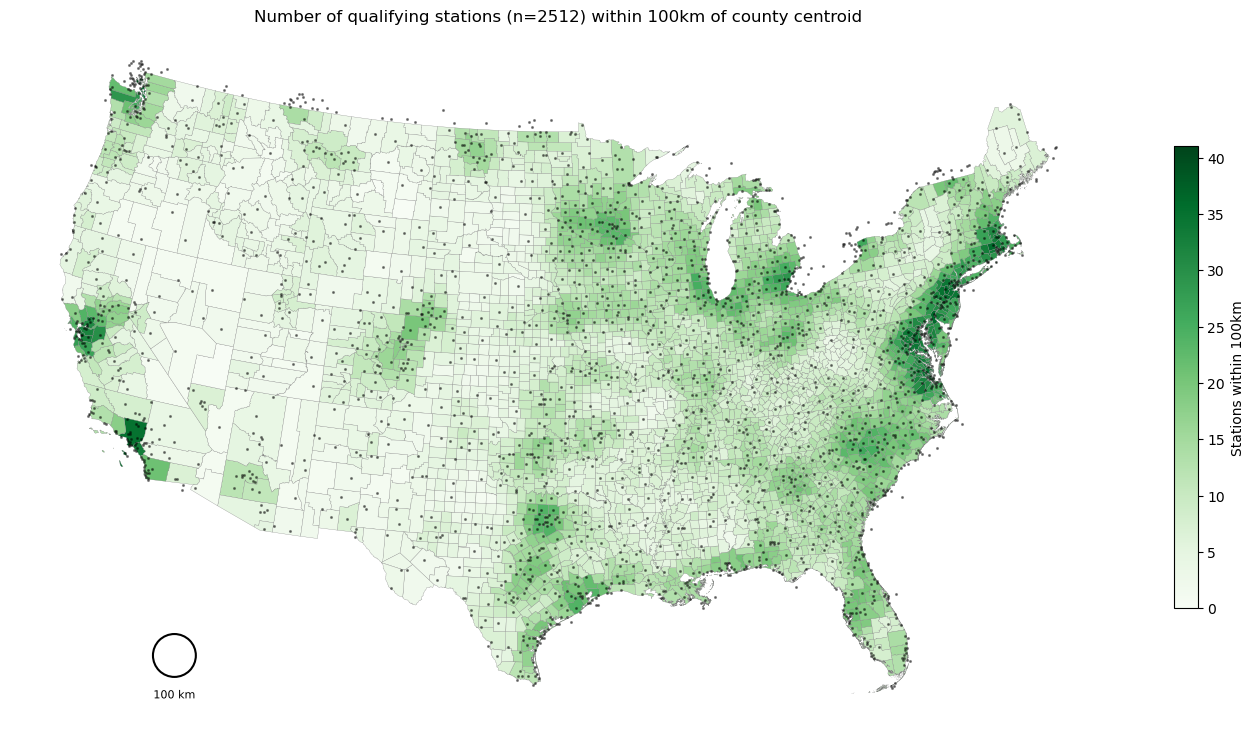

In [116]:
from matplotlib.patches import Circle
import matplotlib.patheffects as pe

# Reproject to Albers Equal Area
counties_plot    = counties.to_crs("EPSG:5070")
stations_plot    = stations_in_county.to_crs("EPSG:5070")

counties_plot["geometry"] = counties_plot.geometry.simplify(1000)  # 1000 meters tolerance in EPSG:5070

fig, ax = plt.subplots(figsize=(14, 8))

counties_plot.plot(
    column="stations_100km",
    cmap="Greens",
    linewidth=0.2,
    edgecolor="grey",
    legend=True,
    legend_kwds={"label": "Stations within 100km", "shrink": 0.6},
    ax=ax,
)
stations_plot.plot(ax=ax, markersize=1.5, color="black", alpha=0.4)

# 100km reference circle in projected meters (EPSG:5070)
xmin, xmax, ymin, ymax = ax.get_xlim()[0], ax.get_xlim()[1], ax.get_ylim()[0], ax.get_ylim()[1]
ref_x = xmin + (xmax - xmin) * 0.15
ref_y = ymin + (ymax - ymin) * 0.1
radius_m     = 100_000  # 100km in meters

circle = Circle(
    (ref_x, ref_y), radius_m,
    fill=False, edgecolor="black", linewidth=1.5,
    zorder=5
)
ax.add_patch(circle)
ax.annotate(
    "100 km", xy=(ref_x, ref_y - 2 * radius_m),
    ha="center", fontsize=8, color="black",
    path_effects=[pe.withStroke(linewidth=2, foreground="white")]
)

ax.set_title(f"Number of qualifying stations (n={len(stations_in_county)}) within 100km of county centroid", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig("station_density.pdf", dpi=300)
plt.show()

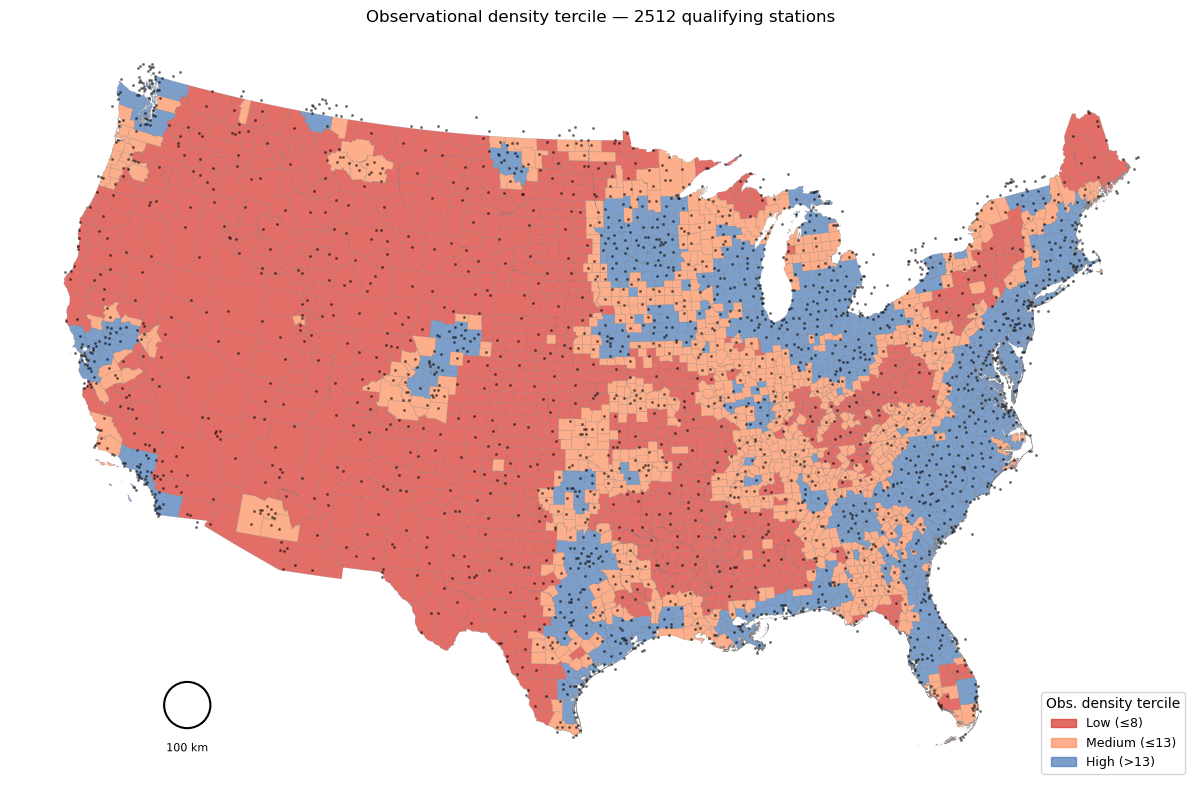

In [31]:
from matplotlib.patches import Circle, Patch
import matplotlib.patheffects as pe

# Add tercile column to counties
tercile_bounds = pd.qcut(
    counties["stations_100km"], q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop",
    retbins=True
)
counties["obs_tercile"] = tercile_bounds[0]
t1, t2 = tercile_bounds[1][1], tercile_bounds[1][2]

counties_plot = counties.to_crs("EPSG:5070")
stations_plot = stations_in_county.to_crs("EPSG:5070")

tercile_colors = {
    "Low"   : "#d73027",
    "Medium": "#fc8d59",
    "High"  : "#4575b4",
}

fig, ax = plt.subplots(figsize=(14, 8))

for tercile, color in tercile_colors.items():
    counties_plot[counties_plot["obs_tercile"] == tercile].plot(
        ax=ax, color=color, linewidth=0.2, edgecolor="grey", alpha=0.7
    )

stations_plot.plot(ax=ax, markersize=1.5, color="black", alpha=0.4)

# 100km reference circle
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ref_x = xmin + (xmax - xmin) * 0.15
ref_y = ymin + (ymax - ymin) * 0.1
circle = Circle(
    (ref_x, ref_y), 100_000,
    fill=False, edgecolor="black", linewidth=1.5, zorder=5
)
ax.add_patch(circle)
ax.annotate(
    "100 km", xy=(ref_x, ref_y - 2 * 100_000),
    ha="center", fontsize=8, color="black",
    path_effects=[pe.withStroke(linewidth=2, foreground="white")]
)

ax.legend(
    handles=[Patch(color=c, alpha=0.7, label=f"{t} (≤{t2:.0f})" if t=="Medium"
                   else f"{t} (≤{t1:.0f})" if t=="Low" else f"{t} (>{t2:.0f})")
             for t, c in tercile_colors.items()],
    title="Obs. density tercile",
    fontsize=9, loc="lower right"
)
ax.set_title(
    f"Observational density tercile — {len(stations_in_county)} qualifying stations",
    fontsize=12
)
ax.axis("off")
plt.tight_layout()
plt.savefig("station_density_tercile.pdf", dpi=300)
plt.show()

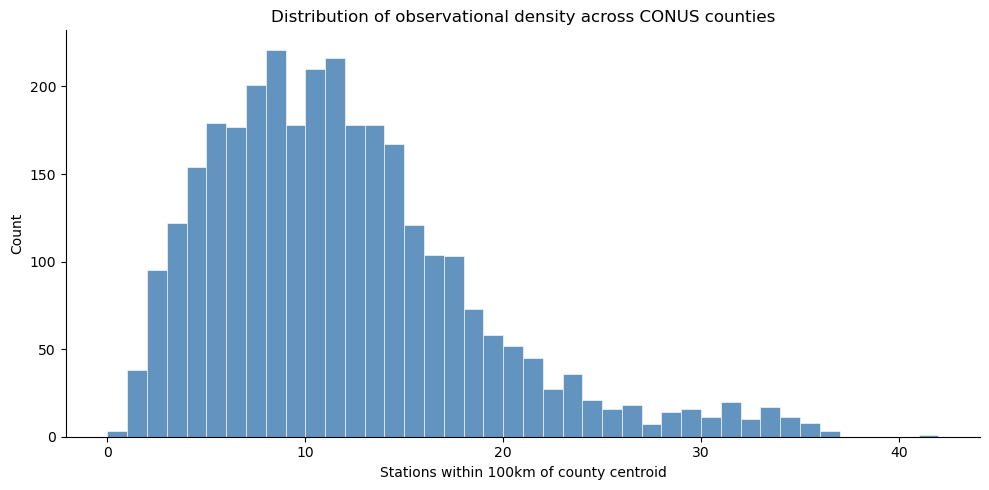

In [126]:
vals = counties["stations_100km"].dropna().values
bins = np.arange(vals.min(), vals.max() + 2, 1)

t1 = np.percentile(vals, 33.3)
t2 = np.percentile(vals, 66.6)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(vals, bins=bins, color="steelblue", alpha=0.85, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Stations within 100km of county centroid")
ax.set_ylabel("Count")
ax.set_title("Distribution of observational density across CONUS counties")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("station_density_hist.pdf", dpi=300)
plt.show()

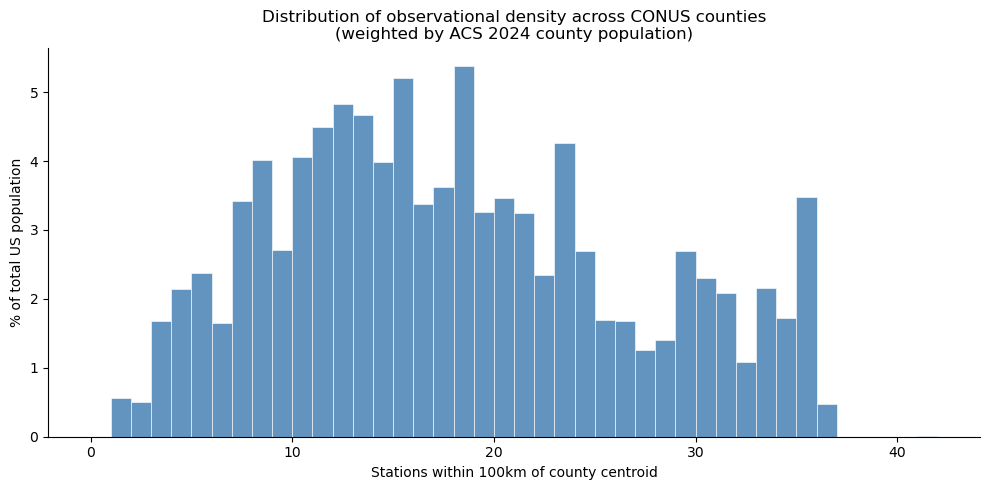

In [125]:
import pandas as pd

acs = pd.read_parquet("/glade/derecho/scratch/dcalhoun/census/data/acs5/acs_5yr_2024/acs_5yr_2024_county.parquet")

# Merge population onto counties by geo_id/GEOID
counties_pop = counties.merge(
    acs[["geo_id", "B01001_001E"]],
    left_on="GEOID",
    right_on="geo_id",
    how="left"
)
counties_pop = counties_pop.rename(columns={"B01001_001E": "population"})

vals = counties_pop["stations_100km"].dropna().values
pop  = counties_pop.loc[counties_pop["stations_100km"].notna(), "population"].values

bins = np.arange(vals.min(), vals.max() + 2, 1)
total_pop = pop.sum()

# Compute population-weighted histogram
weights = (pop / total_pop) * 100  # each county contributes its % of total US population

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(vals, bins=bins, weights=weights, color="steelblue", alpha=0.85, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Stations within 100km of county centroid")
ax.set_ylabel("% of total US population")
ax.set_title("Distribution of observational density across CONUS counties\n(weighted by ACS 2024 county population)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("station_density_hist_population_weighted.pdf", dpi=300)
plt.show()

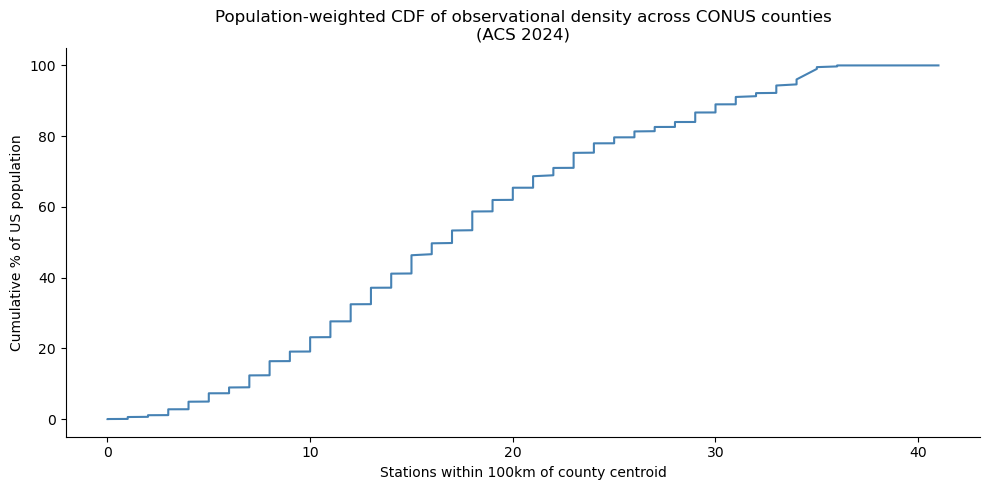

In [127]:
import numpy as np

counties_pop = counties.merge(
    acs[["geo_id", "B01001_001E"]],
    left_on="GEOID",
    right_on="geo_id",
    how="left"
).rename(columns={"B01001_001E": "population"})

valid = counties_pop[counties_pop["stations_100km"].notna()].copy()
vals = valid["stations_100km"].values
pop  = valid["population"].values

# Sort by station density
order     = np.argsort(vals)
vals_sorted = vals[order]
pop_sorted  = pop[order]

# Cumulative population fraction
cum_pop = np.cumsum(pop_sorted) / pop_sorted.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(vals_sorted, cum_pop, color="steelblue", linewidth=1.5)
ax.set_xlabel("Stations within 100km of county centroid")
ax.set_ylabel("Cumulative % of US population")
ax.set_title("Population-weighted CDF of observational density across CONUS counties\n(ACS 2024)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("station_density_cdf_population_weighted.pdf", dpi=300)
plt.show()

In [35]:
out_path = "/glade/derecho/scratch/dcalhoun/aggregated/county_station_density.parquet"
counties[["GEOID", "stations_100km", "obs_tercile"]].rename(
    columns={"GEOID": "geo_id"}
).to_parquet(out_path, index=False)
print(f"Saved {len(counties)} rows → {out_path}")
print(counties["stations_100km"].describe())
print(counties["obs_tercile"].value_counts())

Saved 3109 rows → /glade/derecho/scratch/dcalhoun/aggregated/county_station_density.parquet
count    3109.000000
mean       11.357993
std         6.674703
min         0.000000
25%         7.000000
50%        10.000000
75%        15.000000
max        41.000000
Name: stations_100km, dtype: float64
obs_tercile
Low       1190
Medium     960
High       959
Name: count, dtype: int64


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-04-06 19:52:41,436  WARNING   The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


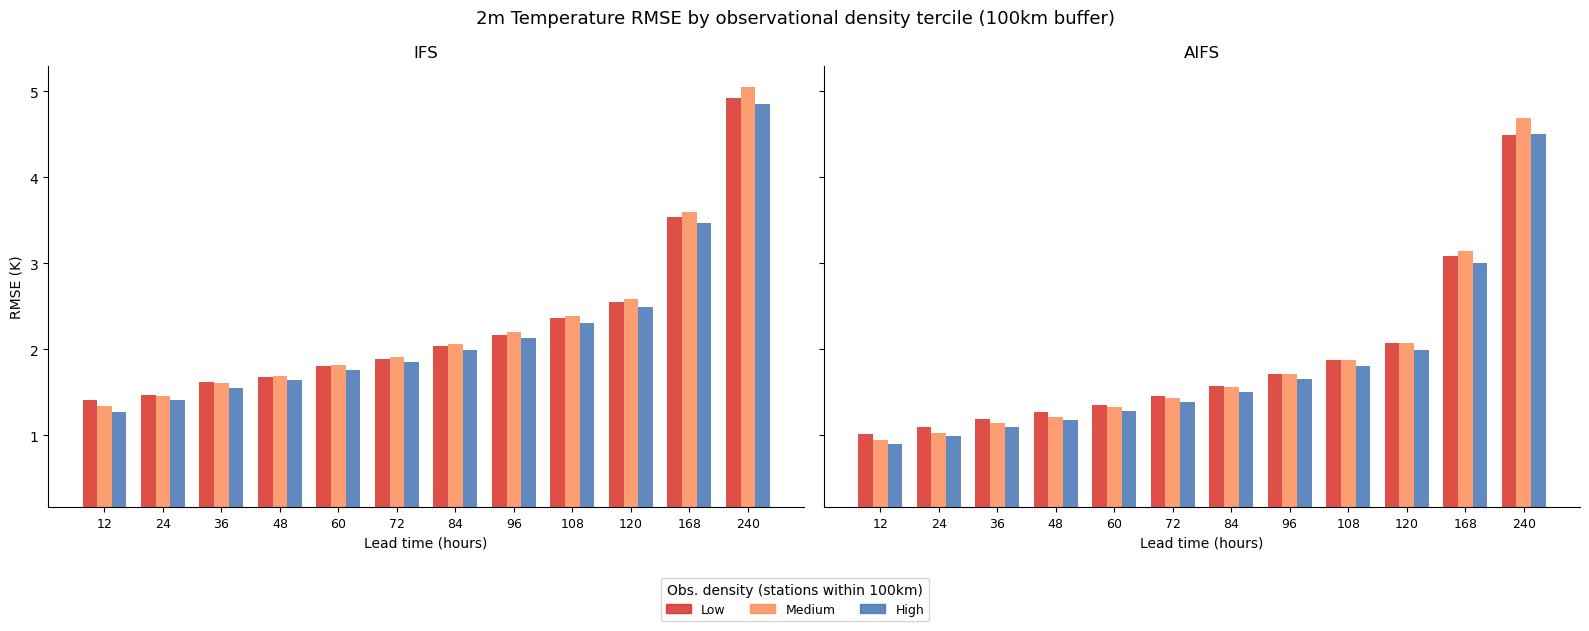

In [13]:
# Build tercile lookup from counties
tercile_lookup = counties[["GEOID", "stations_100km"]].copy()
tercile_lookup["obs_tercile"] = pd.qcut(
    tercile_lookup["stations_100km"], q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)
tercile_rel = duckdb.from_df(tercile_lookup[["GEOID", "obs_tercile"]])

df_tercile_rmse = duckdb.query(f"""
    WITH groups AS (
        SELECT GEOID as geo_id, obs_tercile
        FROM tercile_rel
    ),
    combined AS (
        SELECT 'ifs'  as model, CAST(lead_time AS INT) as lead, geo_id, bias, aland
        FROM read_parquet('{IFS_COUNTY_PATH}')
        UNION ALL
        SELECT 'aifs' as model, CAST(lead_time AS INT) as lead, geo_id, bias, aland
        FROM read_parquet('{AIFS_COUNTY_PATH}')
    )
    SELECT
        c.model,
        c.lead,
        g.obs_tercile,
        SQRT(SUM(c.aland * c.bias * c.bias) / SUM(c.aland)) as rmse
    FROM combined c
    JOIN groups g ON c.geo_id = g.geo_id
    GROUP BY c.model, c.lead, g.obs_tercile
    ORDER BY c.model, c.lead, g.obs_tercile
""").df()

terciles      = ["Low", "Medium", "High"]
tercile_colors = {
    "Low"   : "#d73027",
    "Medium": "#fc8d59",
    "High"  : "#4575b4",
}
x       = np.arange(len(LEADS))
width   = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, model in zip(axes, ["ifs", "aifs"]):
    sub = df_tercile_rmse[df_tercile_rmse["model"] == model]

    for i, tercile in enumerate(terciles):
        g    = sub[sub["obs_tercile"] == tercile].set_index("lead")
        vals = [g.loc[l, "rmse"] if l in g.index else np.nan for l in LEADS]
        ax.bar(x + (i - 1) * width, vals, width=width,
               label=tercile, color=tercile_colors[tercile], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([str(l) for l in LEADS], fontsize=9)
    ax.set_xlabel("Lead time (hours)")
    ax.set_title(model.upper())
    ax.set_ylim(df_tercile_rmse["rmse"].min() - 0.05, None)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("RMSE (K)")
fig.suptitle(
    "2m Temperature RMSE by observational density tercile (100km buffer)",
    fontsize=13
)
plt.tight_layout()
fig.legend(
    handles=[plt.Rectangle((0,0),1,1, color=c, alpha=0.85) for c in tercile_colors.values()],
    labels=terciles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.05),
    title="Obs. density (stations within 100km)",
    fontsize=9,
)
plt.subplots_adjust(bottom=0.15)
plt.savefig("rmse_by_lead_obs.pdf", dpi=300)
plt.show()

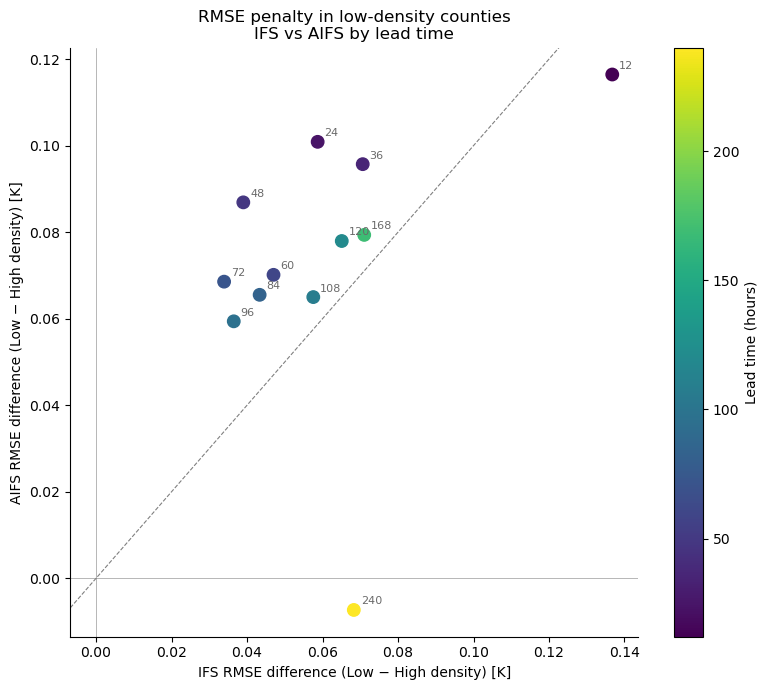

In [61]:
fig, ax = plt.subplots(figsize=(8, 7))

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=min(LEADS), vmax=max(LEADS))

ifs_sub  = df_tercile_rmse[df_tercile_rmse["model"] == "ifs"].set_index(["lead", "obs_tercile"])
aifs_sub = df_tercile_rmse[df_tercile_rmse["model"] == "aifs"].set_index(["lead", "obs_tercile"])

xs, ys, cs = [], [], []
for lead in LEADS:
    try:
        ifs_diff  = (ifs_sub.loc[(lead,  "Low"), "rmse"] -
                     ifs_sub.loc[(lead,  "High"), "rmse"])
        aifs_diff = (aifs_sub.loc[(lead, "Low"), "rmse"] -
                     aifs_sub.loc[(lead, "High"), "rmse"])
    except KeyError:
        continue
    xs.append(ifs_diff)
    ys.append(aifs_diff)
    cs.append(lead)

sc = ax.scatter(xs, ys, c=cs, cmap=cmap, norm=norm, s=80, zorder=3)

ax.axline((0, 0), slope=1, color="grey", linewidth=0.8, linestyle="--", label="1:1")
ax.axhline(0, color="grey", linewidth=0.4)
ax.axvline(0, color="grey", linewidth=0.4)

for x, y, lead in zip(xs, ys, cs):
    ax.annotate(str(lead), (x, y), textcoords="offset points",
                xytext=(5, 4), fontsize=8, color="dimgrey")

plt.colorbar(sc, ax=ax, label="Lead time (hours)")
ax.set_xlabel("IFS RMSE difference (Low − High density) [K]")
ax.set_ylabel("AIFS RMSE difference (Low − High density) [K]")
ax.set_title("RMSE penalty in low-density counties\nIFS vs AIFS by lead time")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [26]:
def plot_county_high_rmse_frequency(model, lead, geo_path, threshold=0.10):
    path = IFS_COUNTY_PATH if model == "ifs" else AIFS_COUNTY_PATH
    p = 1.0 - threshold

    print("Querying...")
    df = duckdb.query(f"""
        WITH county_rmse AS (
            SELECT geo_id,
                valid_time,
                SQRT(AVG(bias**2)) as rmse
            FROM read_parquet('{path}')
            WHERE CAST(lead_time AS INT) = {lead}
            GROUP BY geo_id, valid_time
        ),
        thresholds AS (
            SELECT valid_time,
                QUANTILE_CONT(rmse, {p}) as threshold
            FROM county_rmse
            GROUP BY valid_time
        ),
        exceedances AS (
            SELECT c.geo_id,
                CASE WHEN c.rmse >= t.threshold THEN 1 ELSE 0 END as exceeded
            FROM county_rmse c
            JOIN thresholds t ON c.valid_time = t.valid_time
        )
        SELECT geo_id, SUM(exceeded) as n_exceed, COUNT(*) as n_total,
            100.0 * SUM(exceeded) / COUNT(*) as pct_exceed
        FROM exceedances
        GROUP BY geo_id
    """).df()
    print("Done. Plotting...")

    gdf_all = gpd.read_file(geo_path).rename(columns={"GEOID": "geo_id"}).to_crs("EPSG:4326")
    gdf = gdf_all.merge(df, on="geo_id", how="inner")

    vmin = gdf["pct_exceed"].quantile(0.05)
    vmax = gdf["pct_exceed"].quantile(0.95)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(1, 1, figsize=(18, 8))
    gdf.plot(ax=ax, color="none", edgecolor="black", linewidth=0.3)
    gdf.plot(column="pct_exceed", ax=ax, cmap="YlOrRd", norm=norm, legend=True,
             edgecolor="black", linewidth=0.3,
             legend_kwds={"label": f"% of times in top {int(threshold*100)}% RMSE", "shrink": 0.5})
    ax.axis("off")
    ax.set_title(f"{model.upper()} — Frequency of High RMSE Counties (top {int(threshold*100)}%)\nlead={lead}h", x=0.5)
    plt.tight_layout()
    plt.show()

Querying...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done. Plotting...


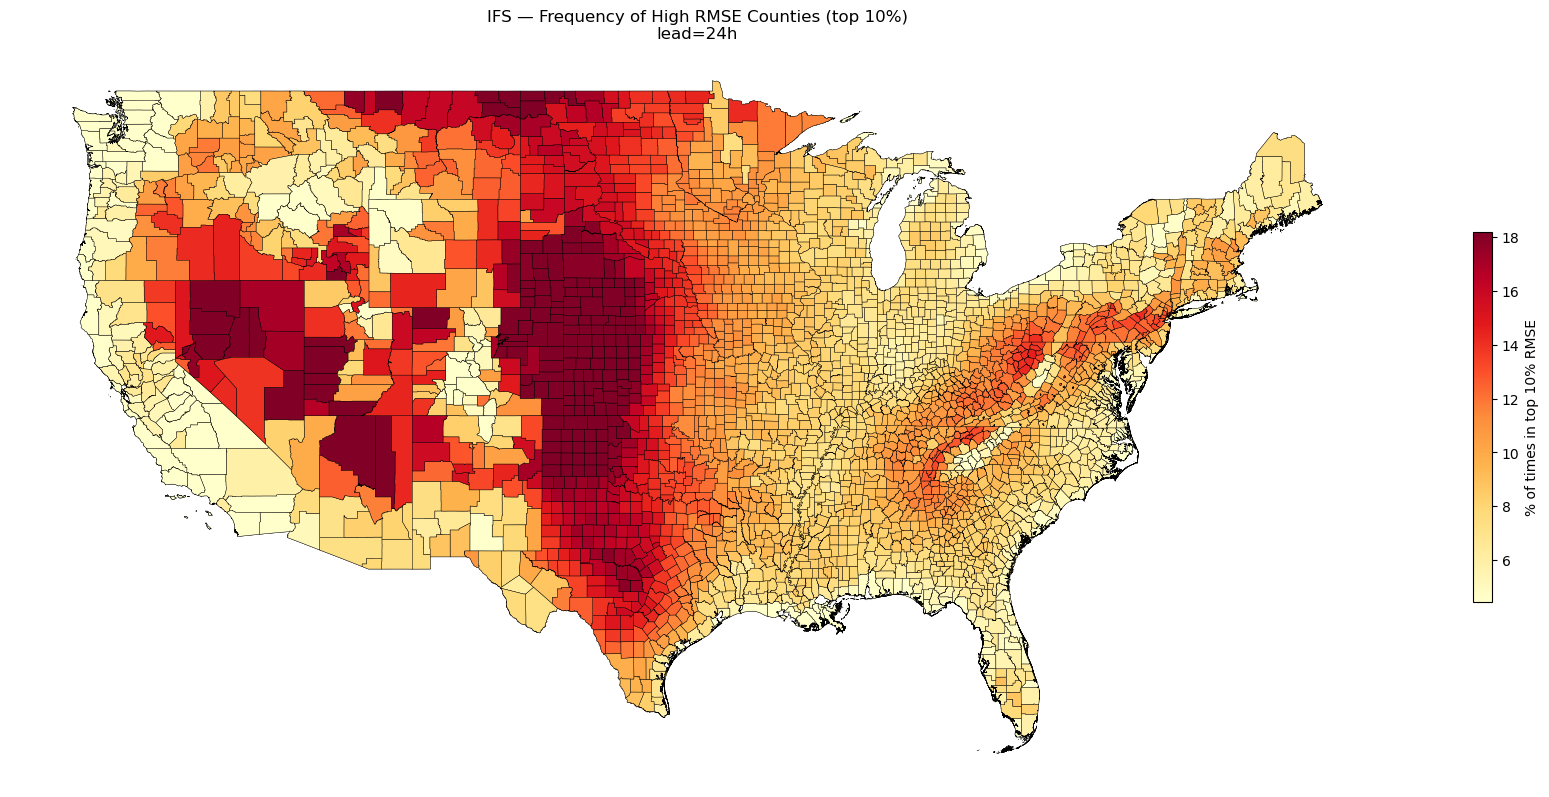

In [28]:
plot_county_high_rmse_frequency("ifs", 24, COUNTY_SHP)

Querying...
Done. Plotting...


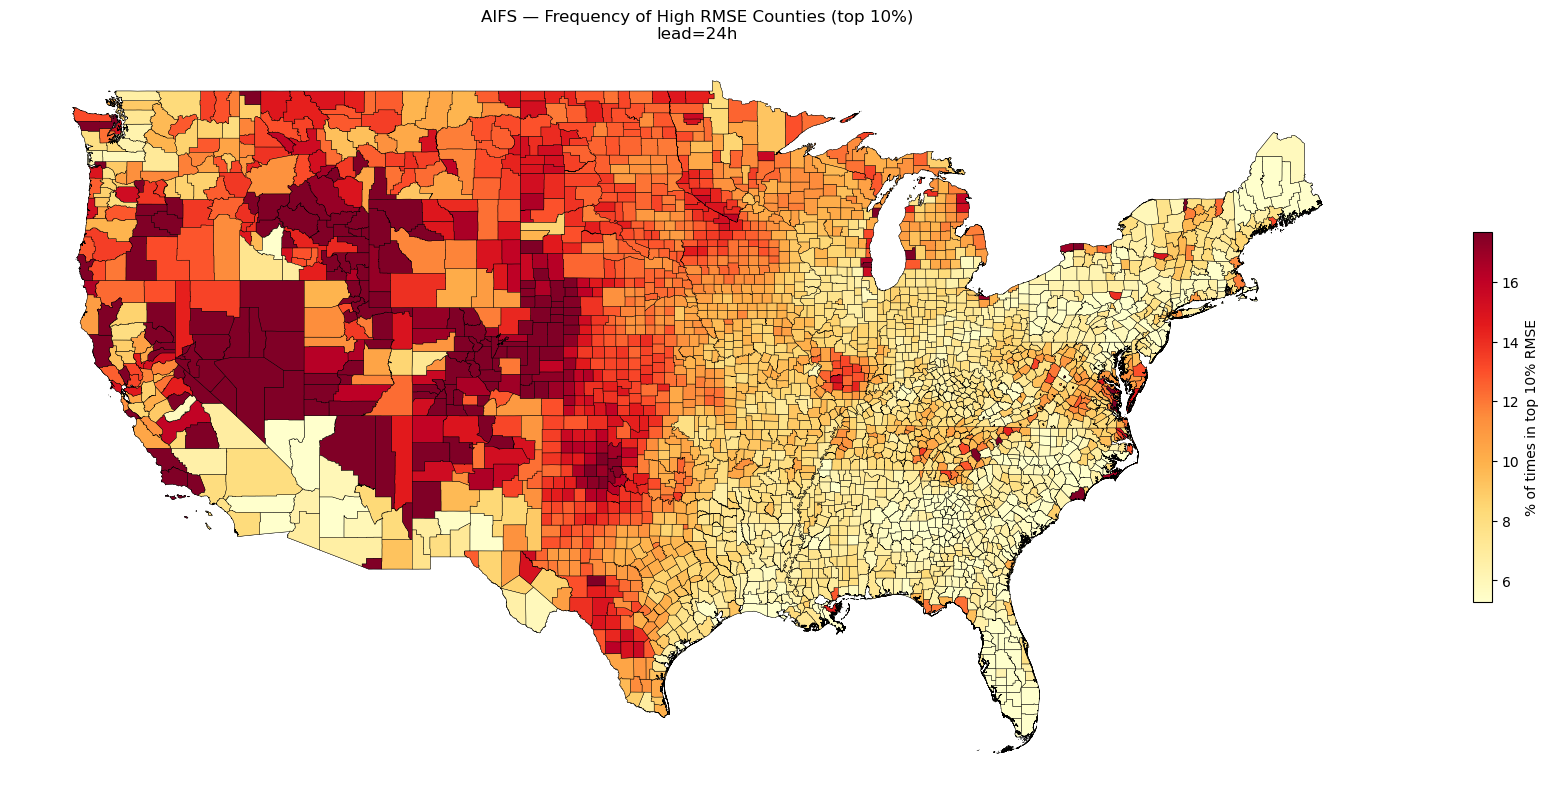

In [27]:
plot_county_high_rmse_frequency("aifs", 24, COUNTY_SHP)

Querying...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done. Plotting...


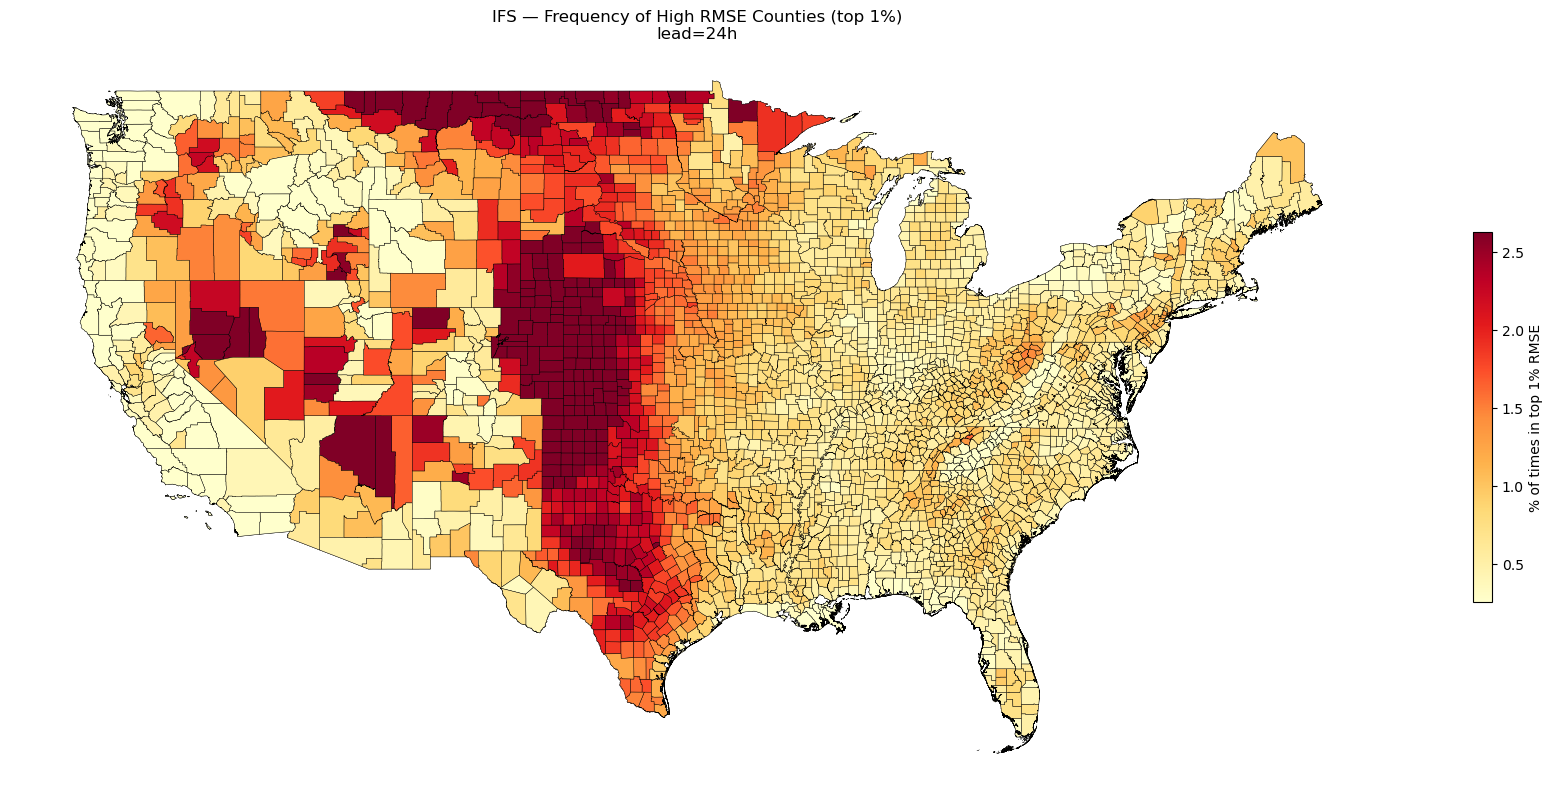

In [31]:
plot_county_high_rmse_frequency("ifs", 24, COUNTY_SHP, threshold=0.01)

Querying...
Done. Plotting...


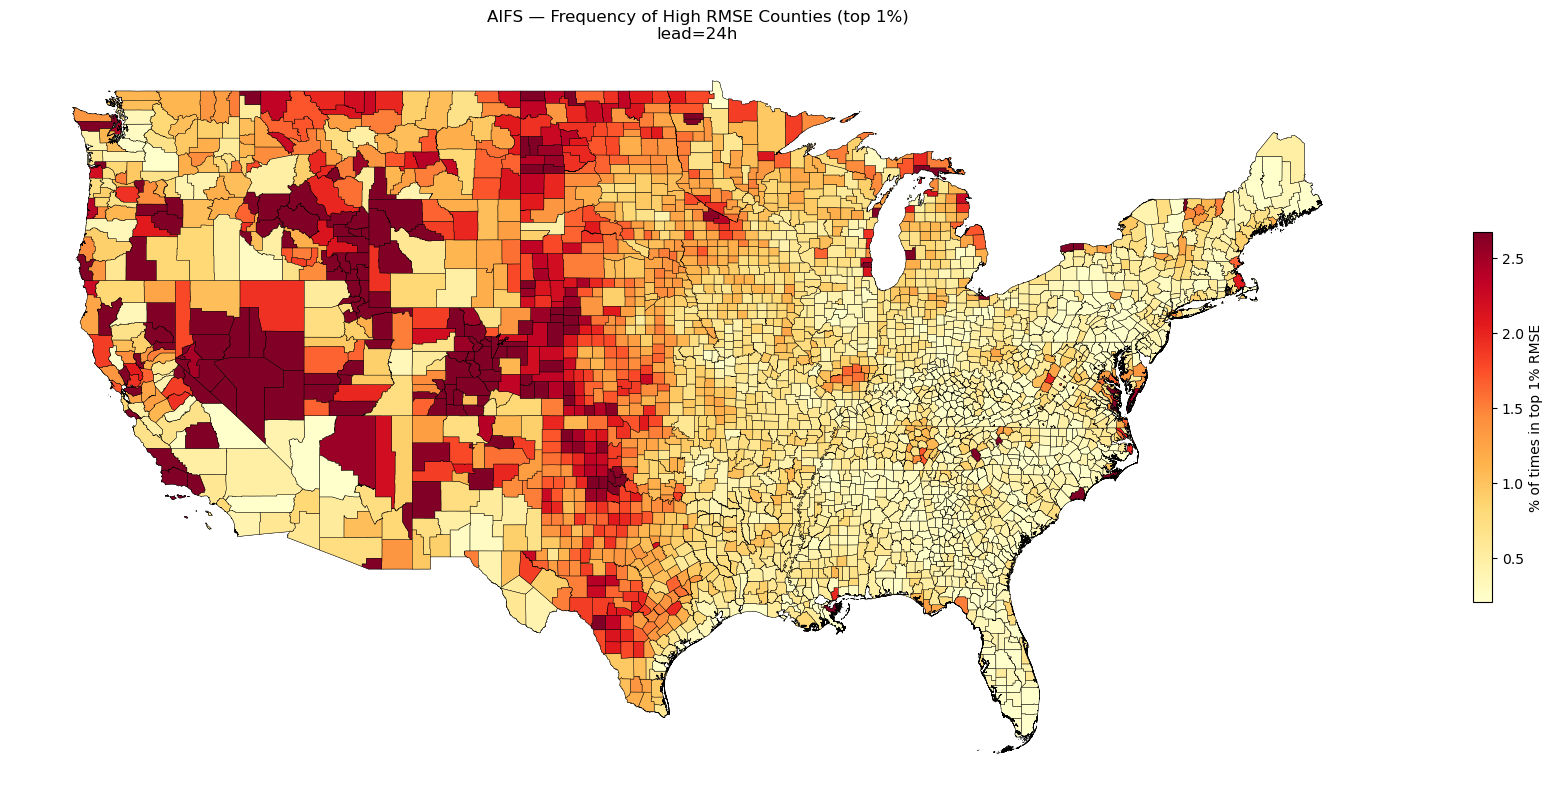

In [30]:
plot_county_high_rmse_frequency("aifs", 24, COUNTY_SHP, threshold=0.01)

In [117]:
def plot_county_high_mae_frequency(model, lead, geo_path, threshold=0.10):
    path = IFS_COUNTY_PATH if model == "ifs" else AIFS_COUNTY_PATH
    p = 1.0 - threshold
    print("Querying...")
    df = duckdb.query(f"""
        WITH county_mae AS (
            SELECT geo_id,
                valid_time,
                AVG(ABS(bias)) as mae
            FROM read_parquet('{path}')
            WHERE CAST(lead_time AS INT) = {lead}
            GROUP BY geo_id, valid_time
        ),
        thresholds AS (
            SELECT valid_time,
                QUANTILE_CONT(mae, {p}) as threshold
            FROM county_mae
            GROUP BY valid_time
        ),
        exceedances AS (
            SELECT c.geo_id,
                CASE WHEN c.mae >= t.threshold THEN 1 ELSE 0 END as exceeded
            FROM county_mae c
            JOIN thresholds t ON c.valid_time = t.valid_time
        )
        SELECT geo_id, SUM(exceeded) as n_exceed, COUNT(*) as n_total,
            100.0 * SUM(exceeded) / COUNT(*) as pct_exceed
        FROM exceedances
        GROUP BY geo_id
    """).df()
    print("Done. Plotting...")
    gdf_all = gpd.read_file(geo_path).rename(columns={"GEOID": "geo_id"}).to_crs("EPSG:5070")
    gdf_all["geometry"] = gdf_all.geometry.simplify(1000)
    gdf = gdf_all.merge(df, on="geo_id", how="inner")
    vmin = gdf["pct_exceed"].quantile(0.05)
    vmax = gdf["pct_exceed"].quantile(0.95)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    fig, ax = plt.subplots(1, 1, figsize=(18, 8))
    gdf.plot(ax=ax, color="none", edgecolor="black", linewidth=0.3)
    gdf.plot(column="pct_exceed", ax=ax, cmap="YlOrRd", norm=norm, legend=True,
             edgecolor="black", linewidth=0.3,
             legend_kwds={"label": f"% of times in top {int(threshold*100)}% MAE", "shrink": 0.5})
    ax.axis("off")
    ax.set_title(f"{model.upper()} — Frequency of High MAE Counties (top {int(threshold*100)}%)\nlead={lead}h", x=0.5)
    plt.tight_layout()
    filename = f"county_high_mae_freq_{model}_lead{lead}h_top{int(threshold*100)}pct.pdf"
    plt.savefig(filename, dpi=300)
    print(f"Saved to {filename}")
    plt.show()

Querying...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done. Plotting...
Saved to county_high_mae_freq_ifs_lead24h_top10pct.pdf


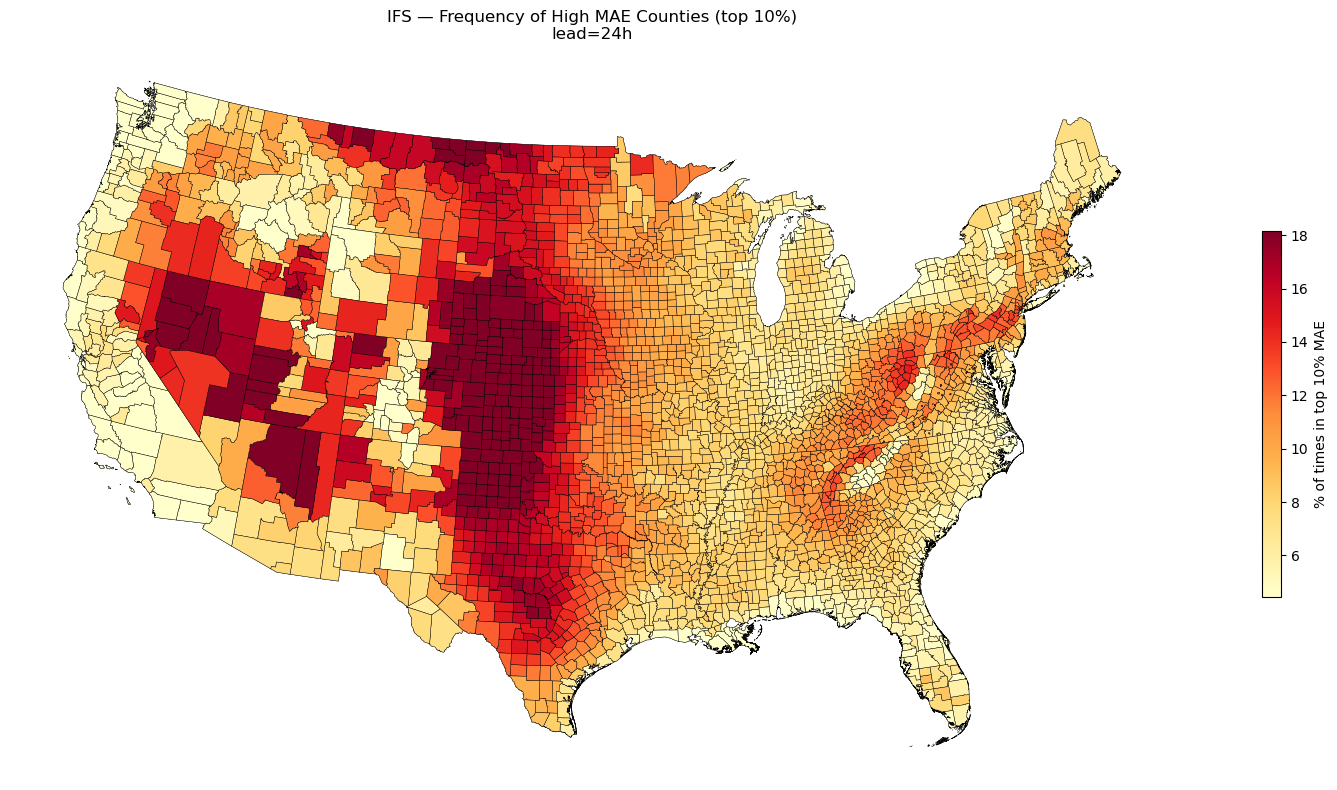

In [118]:
plot_county_high_mae_frequency("ifs", 24, COUNTY_SHP)

Querying...
Done. Plotting...
Saved to county_high_mae_freq_aifs_lead24h_top10pct.pdf


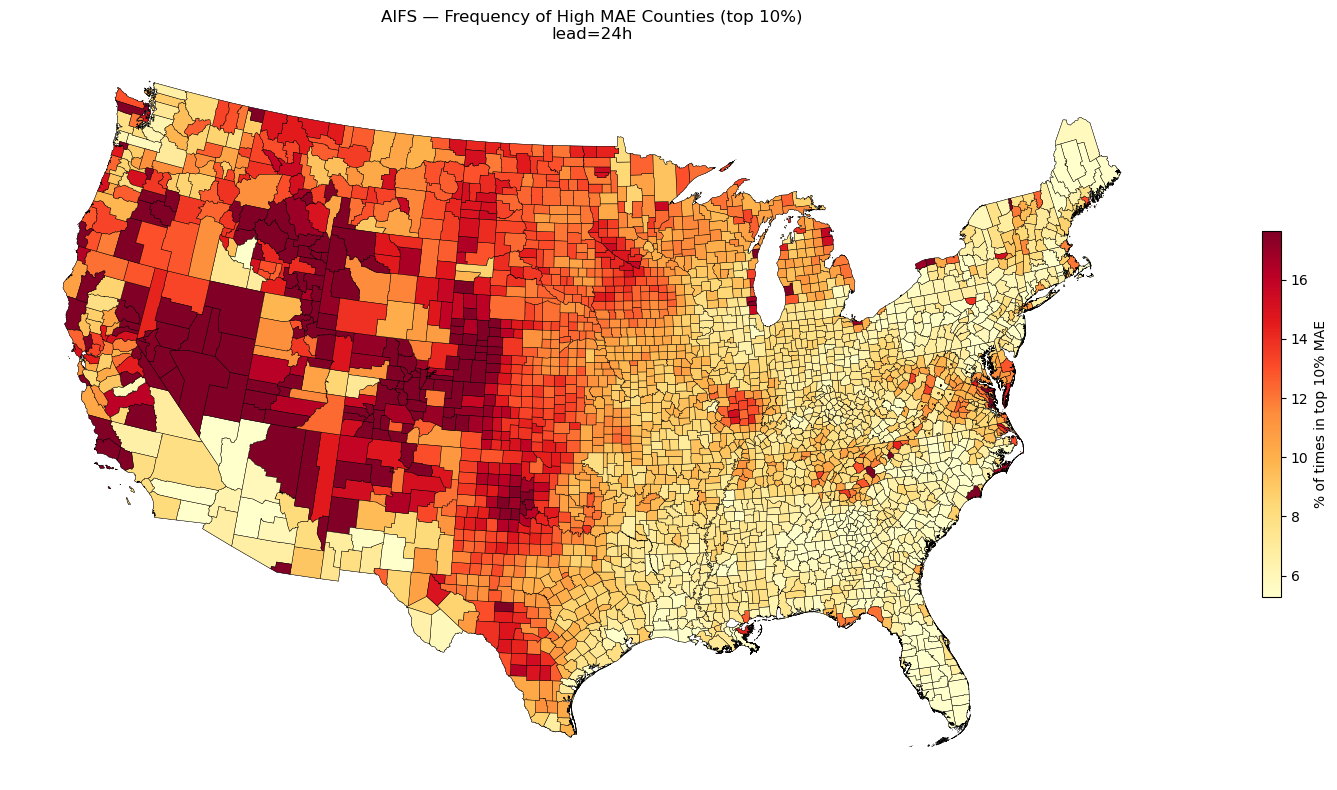

In [119]:
plot_county_high_mae_frequency("aifs", 24, COUNTY_SHP)

In [11]:
threshold = 0.10
p = 1.0 - threshold
records = []

for model, path in [("ifs", IFS_COUNTY_PATH), ("aifs", AIFS_COUNTY_PATH)]:
    for lead in tqdm(LEADS, desc=model):
        df = duckdb.query(f"""
            WITH county_rmse AS (
                SELECT geo_id, valid_time,
                    SQRT(AVG(bias**2)) as rmse
                FROM read_parquet('{path}')
                WHERE CAST(lead_time AS INT) = {lead}
                GROUP BY geo_id, valid_time
            ),
            thresholds AS (
                SELECT valid_time,
                    QUANTILE_CONT(rmse, {p}) as threshold
                FROM county_rmse
                GROUP BY valid_time
            ),
            exceedances AS (
                SELECT c.geo_id,
                    CASE WHEN c.rmse >= t.threshold THEN 1 ELSE 0 END as exceeded
                FROM county_rmse c
                JOIN thresholds t ON c.valid_time = t.valid_time
            )
            SELECT geo_id,
                100.0 * SUM(exceeded) / COUNT(*) as pct_exceed
            FROM exceedances
            GROUP BY geo_id
        """).df()
        df["model"] = model
        df["lead"]  = lead
        records.append(df)

exceed_df = pd.concat(records, ignore_index=True)
print(exceed_df.shape)
print(exceed_df.head())

ifs:   0%|          | 0/12 [00:00<?, ?it/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

aifs:   0%|          | 0/12 [00:00<?, ?it/s]

(74616, 4)
  geo_id  pct_exceed model  lead
0  51590    7.071659   ifs    12
1  29109    8.917026   ifs    12
2  42033    9.253772   ifs    12
3  55037    8.822737   ifs    12
4  06093    9.132543   ifs    12


In [12]:
exceed_100k = exceed_df.merge(
    counties[["GEOID", "stations_100km"]].rename(columns={"GEOID": "geo_id"}),
    on="geo_id", how="inner"
)

exceed_100k["obs_tercile"] = pd.qcut(
    exceed_100k["stations_100km"], q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

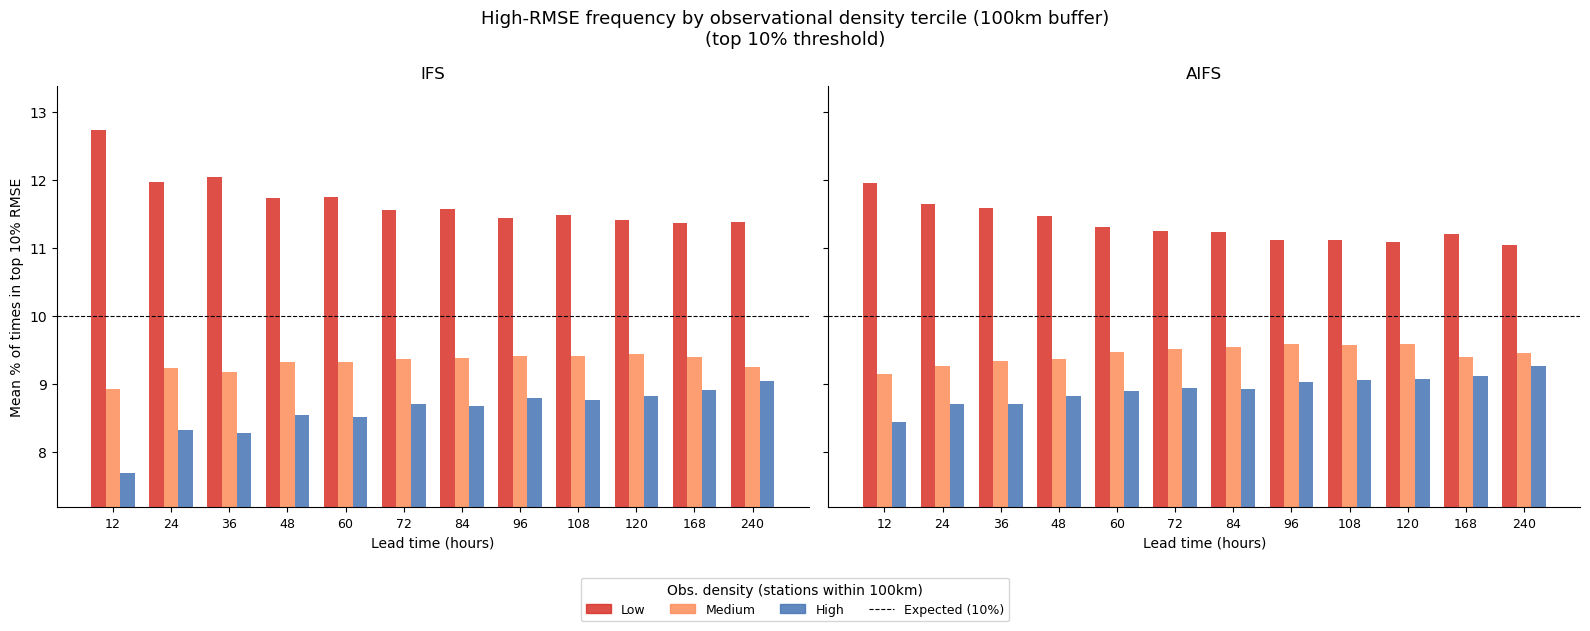

In [13]:
# Compute terciles of stations_100km
exceed_100k["obs_tercile"] = pd.qcut(
    exceed_100k["stations_100km"], q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

# Mean pct_exceed per model, lead, tercile
summary_100k = exceed_100k.groupby(
    ["model", "lead", "obs_tercile"]
)["pct_exceed"].mean().reset_index()

tercile_colors = {
    "Low"   : "#d73027",
    "Medium": "#fc8d59",
    "High"  : "#4575b4",
}
terciles = ["Low", "Medium", "High"]
x        = np.arange(len(LEADS))
width    = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, model in zip(axes, ["ifs", "aifs"]):
    sub = summary_100k[summary_100k["model"] == model]

    for i, tercile in enumerate(terciles):
        g    = sub[sub["obs_tercile"] == tercile].set_index("lead")
        vals = [g.loc[l, "pct_exceed"] if l in g.index else np.nan for l in LEADS]
        ax.bar(x + (i - 1) * width, vals, width=width,
               label=tercile, color=tercile_colors[tercile], alpha=0.85)

    ax.axhline(threshold * 100, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels([str(l) for l in LEADS], fontsize=9)
    ax.set_xlabel("Lead time (hours)")
    ax.set_title(model.upper())
    ax.set_ylim(summary_100k["pct_exceed"].min() - 0.5, None)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(f"Mean % of times in top {int(threshold*100)}% RMSE")
fig.suptitle(
    f"High-RMSE frequency by observational density tercile (100km buffer)\n"
    f"(top {int(threshold*100)}% threshold)",
    fontsize=13
)
plt.tight_layout()
fig.legend(
    handles=[plt.Rectangle((0,0),1,1, color=c, alpha=0.85) for c in tercile_colors.values()] +
            [plt.Line2D([0],[0], color="black", linewidth=0.8, linestyle="--")],
    labels=terciles + [f"Expected ({int(threshold*100)}%)"],
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
    title="Obs. density (stations within 100km)",
    fontsize=9,
)
plt.subplots_adjust(bottom=0.15)
plt.show()

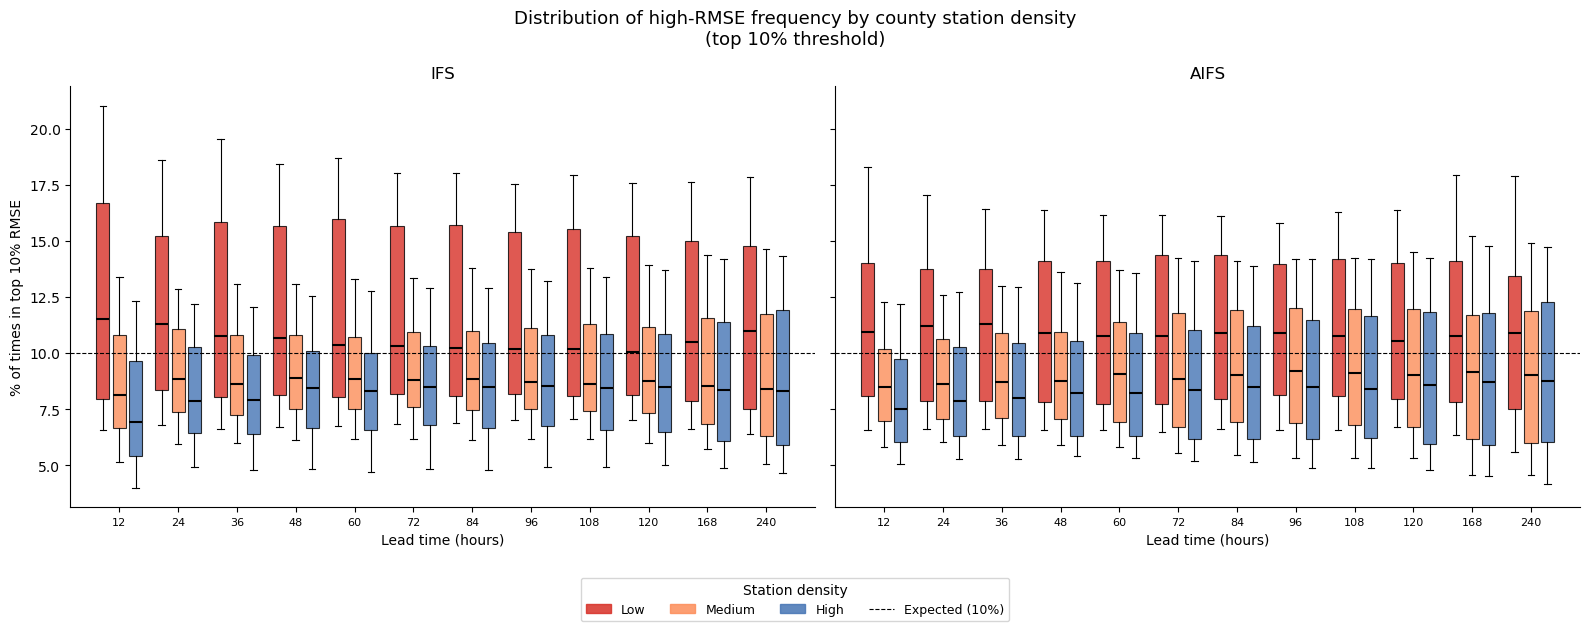

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

groups = ["Low", "Medium", "High"]
group_colors = {
    "Low"   : "#d73027",
    "Medium": "#fc8d59",
    "High"  : "#4575b4",
}

for ax, model in zip(axes, ["ifs", "aifs"]):
    sub = exceed_100k[exceed_100k["model"] == model]

    positions = []
    data      = []
    colors    = []
    xtick_pos = []
    xtick_lab = []

    group_width = 0.25
    gap         = 0.15

    for i, lead in enumerate(LEADS):
        lead_sub  = sub[sub["lead"] == lead]
        center    = i * (3 * group_width + gap)
        xtick_pos.append(center + group_width)
        xtick_lab.append(str(lead))

        for j, group in enumerate(groups):
            vals = lead_sub[lead_sub["obs_tercile"] == group]["pct_exceed"].dropna().values
            positions.append(center + j * group_width)
            data.append(vals)
            colors.append(group_colors[group])

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=group_width * 0.8,
        patch_artist=True,
        showfliers=False,
        whis=(10,90),
        medianprops={"color": "black", "linewidth": 1.5},
        whiskerprops={"linewidth": 0.8},
        capprops={"linewidth": 0.8},
        boxprops={"linewidth": 0.8},
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.axhline(threshold * 100, color="black", linewidth=0.8,
               linestyle="--", label=f"Expected ({int(threshold*100)}%)")
    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_lab, fontsize=8)
    ax.set_xlabel("Lead time (hours)")
    ax.set_title(model.upper())
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

from matplotlib.patches import Patch
axes[0].legend(
    handles=[Patch(color=c, label=g, alpha=0.8) for g, c in group_colors.items()] +
            [plt.Line2D([0], [0], color="black", linewidth=0.8,
                        linestyle="--", label=f"Expected ({int(threshold*100)}%)")],
    title="Station density", fontsize=9
)
axes[0].set_ylabel(f"% of times in top {int(threshold*100)}% RMSE")
fig.suptitle(
    f"Distribution of high-RMSE frequency by county station density\n"
    f"(top {int(threshold*100)}% threshold)",
    fontsize=13
)
plt.tight_layout()
axes[0].get_legend().remove()
fig.legend(
    handles=[plt.Rectangle((0,0),1,1, color=c, alpha=0.85) for c in group_colors.values()] +
            [plt.Line2D([0],[0], color="black", linewidth=0.8, linestyle="--")],
    labels=list(group_colors.keys()) + [f"Expected ({int(threshold*100)}%)"],
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
    title="Station density",
    fontsize=9,
)
plt.subplots_adjust(bottom=0.15)
plt.show()

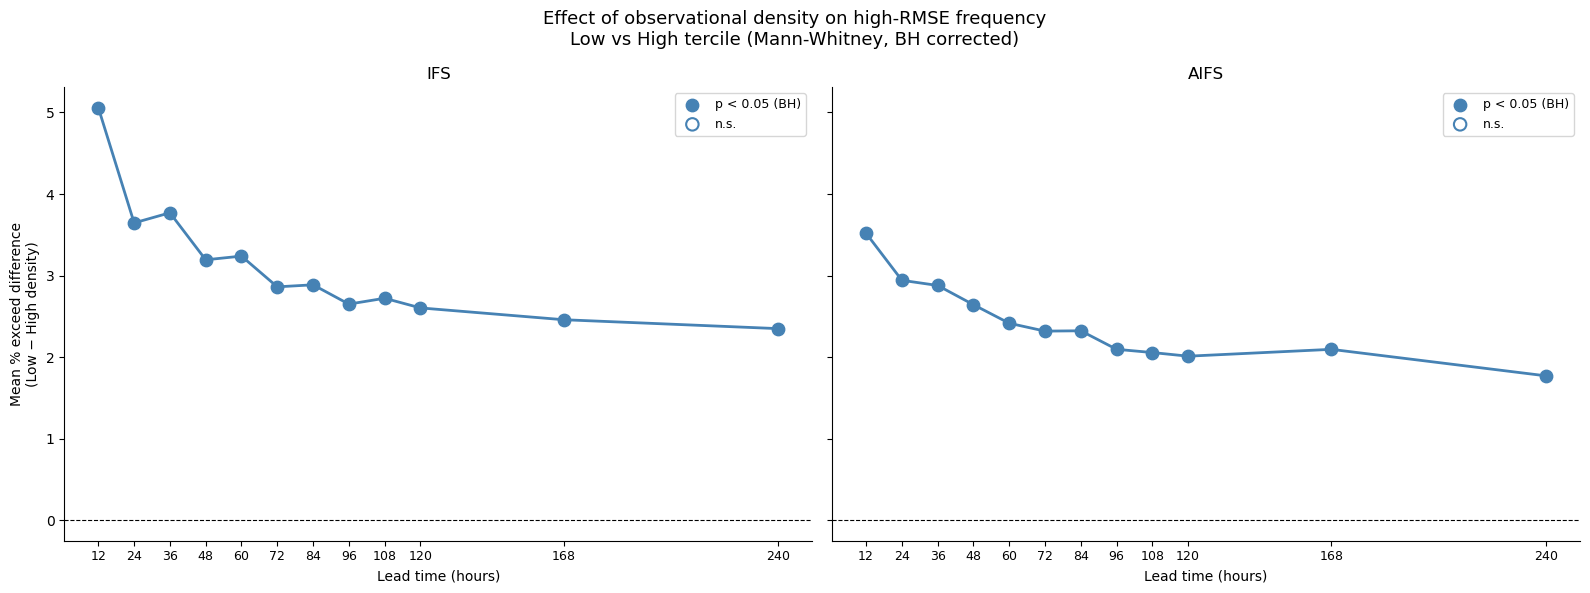

In [43]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

records = []
for model in ["ifs", "aifs"]:
    for lead in LEADS:
        sub = exceed_100k[(exceed_100k["model"] == model) & (exceed_100k["lead"] == lead)]
        g_low  = sub[sub["obs_tercile"] == "Low"]["pct_exceed"].dropna().values
        g_high = sub[sub["obs_tercile"] == "High"]["pct_exceed"].dropna().values

        kw_stat, kw_p = stats.kruskal(
            g_low,
            sub[sub["obs_tercile"] == "Medium"]["pct_exceed"].dropna().values,
            g_high
        )
        mw_stat, mw_p = stats.mannwhitneyu(g_low, g_high, alternative="greater")

        records.append({
            "model"    : model,
            "lead"     : lead,
            "diff"     : g_low.mean() - g_high.mean(),
            "kw_p"     : kw_p,
            "mw_p"     : mw_p,
        })

stats_tercile = pd.DataFrame(records)

_, kw_bh, _, _ = multipletests(stats_tercile["kw_p"], alpha=0.05, method="fdr_bh")
_, mw_bh, _, _ = multipletests(stats_tercile["mw_p"], alpha=0.05, method="fdr_bh")
stats_tercile["kw_sig"] = kw_bh < 0.05
stats_tercile["mw_sig"] = mw_bh < 0.05

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, model in zip(axes, ["IFS", "AIFS"]):
    df       = stats_tercile[stats_tercile["model"] == model.lower()].reset_index(drop=True)
    sig_mask = df["mw_sig"].values

    ax.plot(df["lead"], df["diff"], color="steelblue", linewidth=2, zorder=2)
    ax.scatter(df["lead"][sig_mask],  df["diff"][sig_mask],
               color="steelblue", s=80, zorder=3, label="p < 0.05 (BH)")
    ax.scatter(df["lead"][~sig_mask], df["diff"][~sig_mask],
               color="steelblue", s=80, zorder=3, facecolors="none",
               linewidths=1.5, label="n.s.")

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Lead time (hours)")
    ax.set_title(model)
    ax.set_xticks(df["lead"])
    ax.set_xticklabels(df["lead"], fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Mean % exceed difference\n(Low − High density)")
fig.suptitle(
    "Effect of observational density on high-RMSE frequency\n"
    "Low vs High tercile (Mann-Whitney, BH corrected)",
    fontsize=13
)
plt.tight_layout()
plt.show()

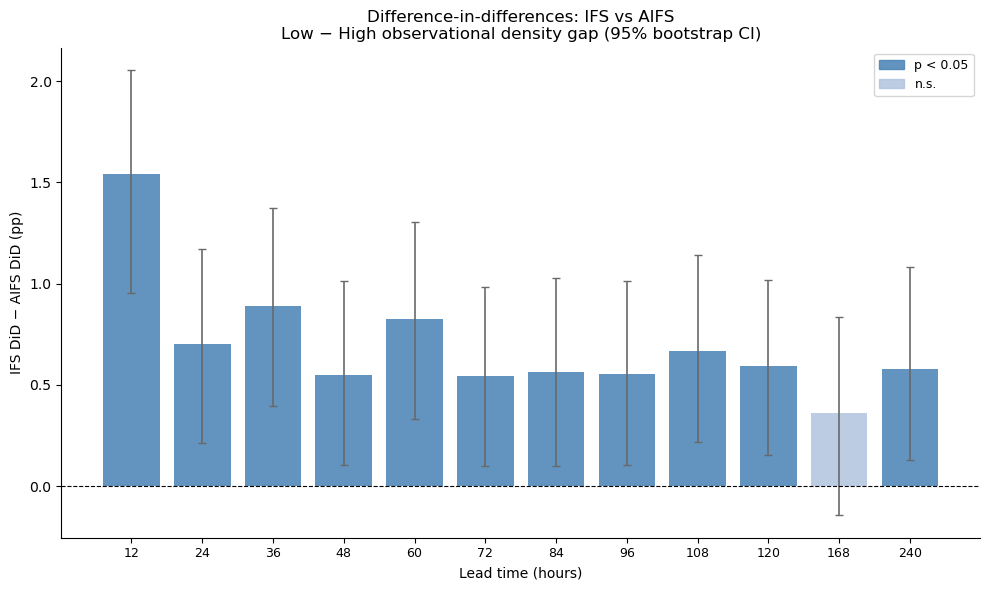

In [44]:
rng = np.random.default_rng(42)
did_tercile_records = []

for lead in LEADS:
    ifs_low   = exceed_100k[(exceed_100k["model"]=="ifs")  & (exceed_100k["lead"]==lead) & (exceed_100k["obs_tercile"]=="Low")]["pct_exceed"].dropna().values
    ifs_high  = exceed_100k[(exceed_100k["model"]=="ifs")  & (exceed_100k["lead"]==lead) & (exceed_100k["obs_tercile"]=="High")]["pct_exceed"].dropna().values
    aifs_low  = exceed_100k[(exceed_100k["model"]=="aifs") & (exceed_100k["lead"]==lead) & (exceed_100k["obs_tercile"]=="Low")]["pct_exceed"].dropna().values
    aifs_high = exceed_100k[(exceed_100k["model"]=="aifs") & (exceed_100k["lead"]==lead) & (exceed_100k["obs_tercile"]=="High")]["pct_exceed"].dropna().values

    boot_ifs_diff  = np.array([
        rng.choice(ifs_low,  len(ifs_low),  replace=True).mean() -
        rng.choice(ifs_high, len(ifs_high), replace=True).mean()
        for _ in range(1000)
    ])
    boot_aifs_diff = np.array([
        rng.choice(aifs_low,  len(aifs_low),  replace=True).mean() -
        rng.choice(aifs_high, len(aifs_high), replace=True).mean()
        for _ in range(1000)
    ])
    boot_did = boot_ifs_diff - boot_aifs_diff

    ifs_diff  = ifs_low.mean()  - ifs_high.mean()
    aifs_diff = aifs_low.mean() - aifs_high.mean()
    did       = ifs_diff - aifs_diff
    p_val     = (boot_did <= 0).mean()

    did_tercile_records.append({
        "lead"     : lead,
        "ifs_diff" : ifs_diff,
        "aifs_diff": aifs_diff,
        "did"      : did,
        "ci_low"   : np.percentile(boot_did, 2.5),
        "ci_high"  : np.percentile(boot_did, 97.5),
        "p_val"    : p_val,
        "sig"      : p_val < 0.05,
    })

did_tercile_df = pd.DataFrame(did_tercile_records)

fig, ax = plt.subplots(figsize=(10, 6))

sig    = did_tercile_df["sig"].values
colors = ["steelblue" if s else "lightsteelblue" for s in sig]

yerr_low  = did_tercile_df["did"] - did_tercile_df["ci_low"]
yerr_high = did_tercile_df["ci_high"] - did_tercile_df["did"]

ax.bar(range(len(did_tercile_df)), did_tercile_df["did"],
       yerr=[yerr_low, yerr_high],
       color=colors, alpha=0.85,
       error_kw={"elinewidth": 1.2, "capsize": 3, "ecolor": "dimgrey"})

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(did_tercile_df)))
ax.set_xticklabels(did_tercile_df["lead"], fontsize=9)
ax.set_xlabel("Lead time (hours)")
ax.set_ylabel("IFS DiD − AIFS DiD (pp)")
ax.set_title(
    "Difference-in-differences: IFS vs AIFS\n"
    "Low − High observational density gap (95% bootstrap CI)",
    fontsize=12
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue",      alpha=0.85, label="p < 0.05"),
    Patch(color="lightsteelblue", alpha=0.85, label="n.s."),
], fontsize=9)

plt.tight_layout()
plt.show()

In [20]:
import geopandas as gpd

acs = gpd.read_parquet(f"{os.environ['SCRATCH']}/census/data/acs5/acs_5yr_2024/acs_5yr_2024_county.parquet")
print(acs.shape)

(3222, 306)


In [21]:
# Build interpretable demographic features
acs["pct_white"]        = acs["B03002_003E"] / acs["B03002_001E"] * 100
acs["pct_black"]        = acs["B03002_004E"] / acs["B03002_001E"] * 100
acs["pct_hispanic"]     = acs["B03002_012E"] / acs["B03002_001E"] * 100
acs["pct_asian"]        = acs["B03002_006E"] / acs["B03002_001E"] * 100
acs["pct_poverty"]      = acs["B17001_002E"] / acs["B17001_001E"] * 100
acs["pct_bachelors"]    = (acs["B15003_022E"] + acs["B15003_023E"] +
                           acs["B15003_024E"] + acs["B15003_025E"]) / acs["B15003_001E"] * 100
acs["pct_unemployed"]   = acs["B23025_005E"] / acs["B23025_002E"] * 100
acs["pct_renter"]       = acs["B25003_003E"] / acs["B25003_001E"] * 100
acs["pct_disabled"]     = (acs["B18101_004E"] + acs["B18101_007E"] +
                           acs["B18101_010E"] + acs["B18101_013E"] +
                           acs["B18101_016E"] + acs["B18101_019E"] +
                           acs["B18101_023E"] + acs["B18101_026E"] +
                           acs["B18101_029E"] + acs["B18101_032E"] +
                           acs["B18101_035E"] + acs["B18101_038E"]) / acs["B18101_001E"] * 100
acs["pct_no_internet"]  = acs["B28002_013E"] / acs["B28002_001E"] * 100
acs["pct_non_english"]  = (acs["C16002_001E"] - acs["C16002_002E"]) / acs["C16002_001E"] * 100
acs["median_income"]    = acs["B19013_001E"]
acs["gini"]             = acs["B19083_001E"]
acs["log_population"]   = np.log1p(acs["B01001_001E"])

demo_vars = {
    "pct_white"       : "% White",
    "pct_black"       : "% Black",
    "pct_hispanic"    : "% Hispanic",
    "pct_asian"       : "% Asian",
    "pct_poverty"     : "% in poverty",
    "pct_bachelors"   : "% Bachelor's+",
    "pct_unemployed"  : "% Unemployed",
    "pct_renter"      : "% Renter-occupied",
    "pct_disabled"    : "% Disabled",
    "pct_no_internet" : "% No internet",
    "pct_non_english" : "% Non-English speaking HH",
    "median_income"   : "Median household income ($)",
    "gini"            : "Gini coefficient",
    "log_population"  : "Log population",
}

# Join station groups to ACS
county_groups = counties[["GEOID", "stations_100km"]].copy()
county_groups["station_group"] = pd.qcut(
    county_groups["stations_100km"], q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

acs_grouped = acs.merge(
    county_groups[["GEOID", "station_group"]],
    left_on="geo_id", right_on="GEOID", how="inner"
)
acs_grouped = acs_grouped[acs_grouped["STATE"].isin(CONUS_FIPS)]

for group in groups:
    pop = acs_grouped[acs_grouped["station_group"] == group]["B01001_001E"].sum()
    n   = (acs_grouped["station_group"] == group).sum()
    print(f"{group:15s}: {n:5d} counties | pop = {pop:>15,.0f}")

Low            :  1190 counties | pop =      54,433,792
Medium         :   960 counties | pop =      69,094,055
High           :   959 counties | pop =     209,213,711


In [22]:
import pandas as pd
kop = pd.read_parquet("/glade/derecho/scratch/dcalhoun/aggregated/koppen_geiger_county.parquet")
print(kop.shape)
print(kop.columns.tolist())
print(kop.head(3).to_string())

(3222, 5)
['geo_id', 'category_1', 'category_1_pct', 'category_2', 'category_2_pct']
  geo_id  category_1  category_1_pct  category_2  category_2_pct
0  01001        14.0           100.0         NaN             0.0
1  01003        14.0           100.0         NaN             0.0
2  01005        14.0           100.0         NaN             0.0


In [23]:
print(kop["category_1"].value_counts().sort_index())

category_1
1.0       76
2.0        4
3.0        9
4.0       20
5.0        7
6.0       29
7.0      267
8.0       25
9.0       57
14.0    1460
15.0      16
17.0       2
18.0      50
19.0       1
21.0       8
22.0       2
23.0       1
25.0     772
26.0     367
27.0      41
29.0       8
Name: count, dtype: int64


In [24]:
koppen_map = {
    1.0 : "Af",   # Tropical rainforest
    2.0 : "Am",   # Tropical monsoon
    3.0 : "Aw",   # Tropical savanna dry winter
    4.0 : "As",   # Tropical savanna dry summer
    5.0 : "BWh",  # Hot desert
    6.0 : "BWk",  # Cold desert
    7.0 : "BSh",  # Hot semi-arid
    8.0 : "BSk",  # Cold semi-arid
    9.0 : "Csa",  # Mediterranean hot summer
    14.0: "Cfa",  # Humid subtropical
    15.0: "Cfb",  # Oceanic
    17.0: "Cwa",  # Monsoon humid subtropical
    18.0: "Cwb",  # Monsoon oceanic
    19.0: "Cwc",  # Monsoon subpolar oceanic
    21.0: "Dsa",  # Continental Mediterranean hot summer
    22.0: "Dsb",  # Continental Mediterranean warm summer
    23.0: "Dsc",  # Continental Mediterranean cool summer
    25.0: "Dfa",  # Humid continental hot summer
    26.0: "Dfb",  # Humid continental warm summer
    27.0: "Dfc",  # Subarctic
    29.0: "Dwa",  # Monsoon continental hot summer
}

# Simplified main class
koppen_main = {
    1.0: "A", 2.0: "A", 3.0: "A", 4.0: "A",
    5.0: "B", 6.0: "B", 7.0: "B", 8.0: "B",
    9.0: "C", 14.0: "C", 15.0: "C", 17.0: "C", 18.0: "C", 19.0: "C",
    21.0: "D", 22.0: "D", 23.0: "D", 25.0: "D", 26.0: "D", 27.0: "D", 29.0: "D",
}

kop["koppen_code"]  = kop["category_1"].map(koppen_map)
kop["koppen_class"] = kop["category_1"].map(koppen_main)

print(kop[["geo_id", "category_1", "koppen_code", "koppen_class"]].head(10))
print("\nClass distribution:")
print(kop["koppen_class"].value_counts())

  geo_id  category_1 koppen_code koppen_class
0  01001        14.0         Cfa            C
1  01003        14.0         Cfa            C
2  01005        14.0         Cfa            C
3  01007        14.0         Cfa            C
4  01009        14.0         Cfa            C
5  01011        14.0         Cfa            C
6  01013        14.0         Cfa            C
7  01015        14.0         Cfa            C
8  01017        14.0         Cfa            C
9  01019        14.0         Cfa            C

Class distribution:
koppen_class
C    1586
D    1199
B     328
A     109
Name: count, dtype: int64


In [31]:
def plot_weightmap_comparison(geoid, cache_dir=None, shapefile_path=None):
    """
    Plot weightmap pixel overlaps for a given county GEOID across all three
    cached weightmaps (IFS 0.125°, AIFS 0.25°, ERA5 0.25°).

    Cells are colored by overlap area relative to the largest pixel overlap
    in each panel, matching the xagg diagnostic convention.

    Parameters
    ----------
    geoid : str
        5-digit county FIPS code (e.g. '20091' for Johnson County, KS).
    cache_dir : str, optional
        Path to weightmap cache directory. Defaults to WEIGHTMAP_CACHE_DIR.
    shapefile_path : str, optional
        Path to county shapefile. Defaults to SHAPEFILE_PATH.
    """
    import glob
    import os
    import pickle

    import geopandas as gpd
    import matplotlib.patches as mpatches
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import numpy as np
    import sys
    sys.path.insert(0, "/glade/u/home/dcalhoun/nwp-census-eval/scripts")
    from config import WEIGHTMAP_CACHE_DIR as _CACHE_DIR, SHAPEFILE_PATH as _SHP

    cache_dir      = cache_dir or _CACHE_DIR
    shapefile_path = shapefile_path or _SHP

    # Load and identify weightmaps by resolution and extent
    wm_paths = sorted(glob.glob(os.path.join(cache_dir, "weightmap_*.pkl")))
    if not wm_paths:
        raise FileNotFoundError(f"No cached weightmaps found in {cache_dir}")

    weightmaps = {}
    for p in wm_paths:
        with open(p, "rb") as f:
            wm = pickle.load(f)
        lats      = np.unique(wm.source_grid["lat"].values)
        lons      = np.unique(wm.source_grid["lon"].values)
        dlat      = float(np.abs(np.diff(lats)).mean()) if len(lats) > 1 else 0.25
        is_global = lons.min() < -150

        if round(dlat, 4) == 0.1250:
            weightmaps["ifs"] = wm
        elif is_global:
            weightmaps["era5"] = wm
        else:
            weightmaps["aifs"] = wm

    ordered_keys   = ["ifs", "aifs"]
    ordered_labels = ["0.125°", "0.25°"]

    # Load county
    counties    = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
    test_county = counties[counties["GEOID"] == geoid]
    if test_county.empty:
        raise ValueError(f"GEOID {geoid} not found in shapefile.")
    county_idx  = test_county.index[0]
    county_name = test_county["NAMELSAD"].values[0]

    # Shared plot extent
    bounds = test_county.total_bounds
    pad    = 0.25
    xlim   = (bounds[0] - pad, bounds[2] + pad)
    ylim   = (bounds[1] - pad, bounds[3] + pad)

    cmap = plt.cm.Blues
    fig, axes = plt.subplots(1, len(ordered_keys), figsize=(16, 9))

    for ax, key, label in zip(axes, ordered_keys, ordered_labels):
        if key not in weightmaps:
            ax.set_title(f"{label}\nNot found in cache")
            ax.set_xlim(xlim); ax.set_ylim(ylim)
            continue

        wm  = weightmaps[key]
        row = wm.agg[wm.agg["poly_idx"] == county_idx]
        if row.empty:
            ax.set_title(f"{label}\nNo overlap for GEOID {geoid}")
            ax.set_xlim(xlim); ax.set_ylim(ylim)
            continue

        row      = row.iloc[0]
        coords   = row["coords"]
        rel_area = np.array(row["rel_area"]).ravel()
        lats     = np.array([c[0] for c in coords])
        lons     = np.array([c[1] for c in coords])

        ulats = np.unique(lats)
        ulons = np.unique(lons)
        dlat  = float(np.diff(ulats).mean()) if len(ulats) > 1 else 0.25
        dlon  = float(np.diff(ulons).mean()) if len(ulons) > 1 else 0.25

        # Normalize relative to largest pixel — darkest cell = 1.0
        rel_area_norm = rel_area / rel_area.max()
        panel_norm    = mcolors.Normalize(vmin=0, vmax=1)

        # Draw weighted cells using normalized values for color
        for (lat, lon), w in zip(coords, rel_area_norm):
            rect = mpatches.Rectangle(
                (lon - dlon / 2, lat - dlat / 2), dlon, dlat,
                linewidth=1.5, edgecolor="steelblue",
                facecolor=cmap(panel_norm(w)),
                zorder=2,
            )
            ax.add_patch(rect)

        # Grid overlay in black
        sg       = wm.source_grid
        all_lats = np.unique(sg["lat"].values)
        all_lons = np.unique(sg["lon"].values)
        all_lats = all_lats[(all_lats >= ylim[0] - dlat) & (all_lats <= ylim[1] + dlat)]
        all_lons = all_lons[(all_lons >= xlim[0] - dlon) & (all_lons <= xlim[1] + dlon)]
        lat_edges = np.concatenate([[all_lats[0]  - dlat / 2],
                                     all_lats[:-1] + np.diff(all_lats) / 2,
                                    [all_lats[-1]  + dlat / 2]])
        lon_edges = np.concatenate([[all_lons[0]  - dlon / 2],
                                     all_lons[:-1] + np.diff(all_lons) / 2,
                                    [all_lons[-1]  + dlon / 2]])
        for le in lat_edges:
            ax.axhline(le, color="black", linewidth=0.4, alpha=0.5, zorder=1)
        for le in lon_edges:
            ax.axvline(le, color="black", linewidth=0.4, alpha=0.5, zorder=1)

        # Surrounding counties in purple
        counties.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]].boundary.plot(
            ax=ax, color="purple", linewidth=0.5, zorder=3
        )
        # Test county in red on top
        test_county.boundary.plot(ax=ax, color="red", linewidth=2, zorder=5)

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect("equal")
        ax.set_title(f"{label}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        # Per-panel colorbar beneath each axis
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=panel_norm)
        sm.set_array([])
        fig.colorbar(
            sm, ax=ax,
            label="Overlap area (relative to largest pixel overlap)",
            orientation="horizontal",
            pad=0.08,
            shrink=0.8,
            fraction=0.046,
        )

    plt.suptitle(
        f"Weightmap pixel overlaps — {county_name} (geo_id {geoid})",
        fontsize=12,
    )
    plt.tight_layout()
    plt.savefig("weightmap_comparison.pdf", dpi=300)
    plt.show()

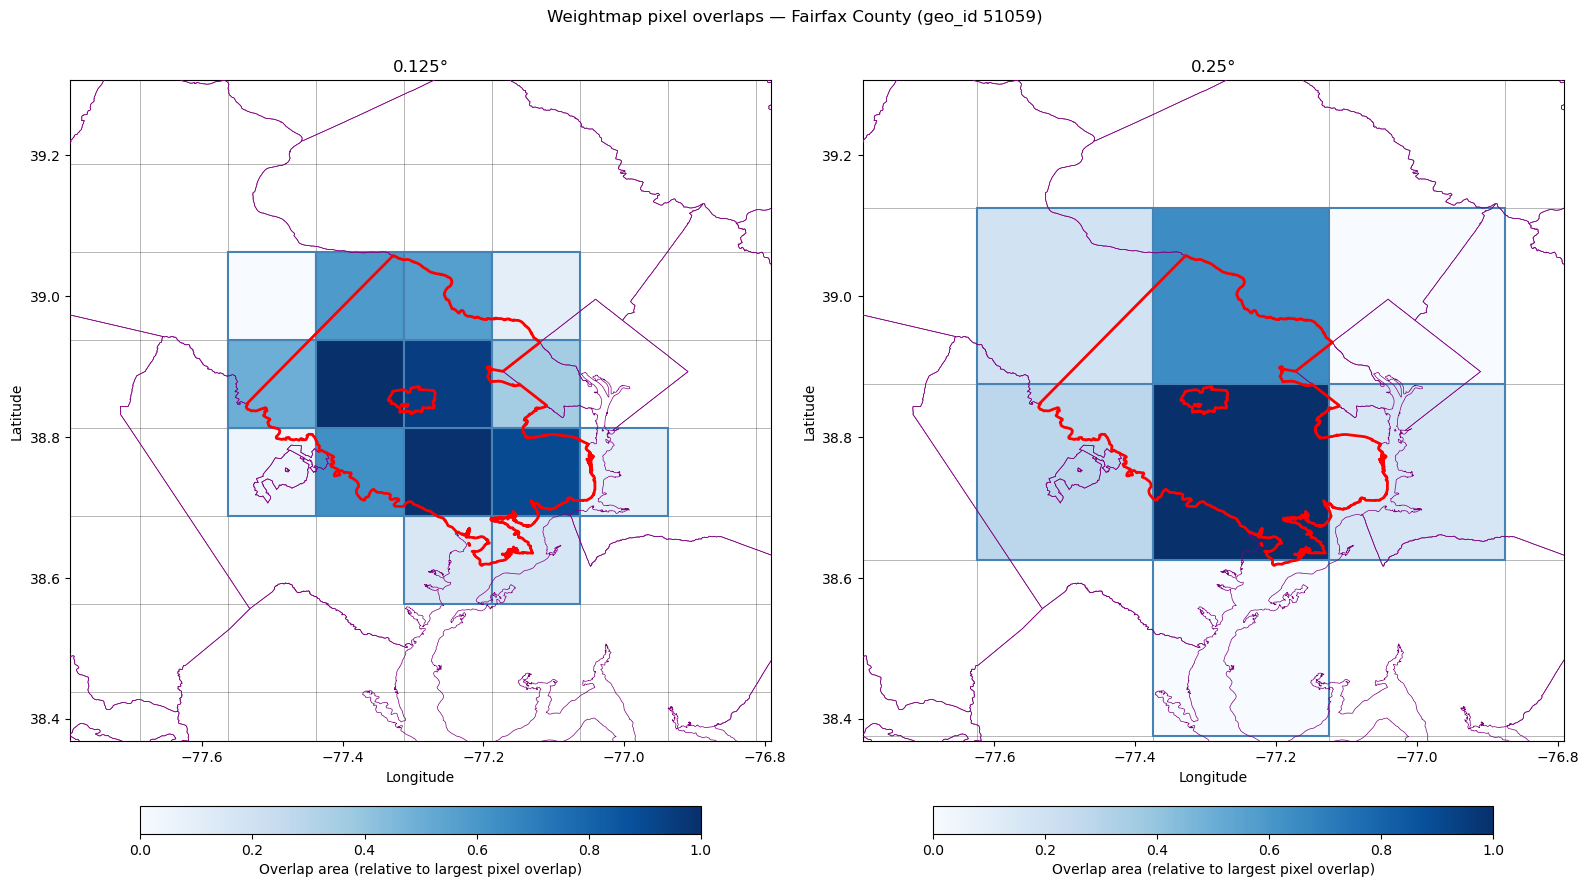

In [32]:
plot_weightmap_comparison("51059")

In [1]:
import duckdb

# Check date ranges and row counts in each parquet
for model in ["ifs", "aifs"]:
    path = f"/glade/derecho/scratch/dcalhoun/aggregated/{model}_fc_bias_anom_2t_county.parquet"
    result = duckdb.query(f"""
        SELECT 
            COUNT(*) as n_rows,
            COUNT(DISTINCT geo_id) as n_counties,
            COUNT(DISTINCT lead_time) as n_leads,
            MIN(valid_time) as min_valid,
            MAX(valid_time) as max_valid,
            MIN(init_time) as min_init,
            MAX(init_time) as max_init,
            COUNT(DISTINCT HOUR(valid_time)) as n_valid_hours,
            LIST(DISTINCT HOUR(valid_time)) as valid_hours,
            COUNT(DISTINCT lead_time) as n_leads,
            LIST(DISTINCT lead_time) as leads
        FROM read_parquet('{path}')
    """).df()
    print(f"\n=== {model.upper()} ===")
    print(result.T.to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


=== IFS ===
                                                                            0
n_rows                                                              346218240
n_counties                                                               3109
n_leads                                                                    15
min_valid                                                 2016-01-01 00:00:00
max_valid                                                 2026-03-10 12:00:00
min_init                                                  2016-01-01 00:00:00
max_init                                                  2026-02-28 12:00:00
n_valid_hours                                                               4
valid_hours                                                    [0, 18, 12, 6]
n_leads_1                                                                  15
leads          [0, 168, 96, 60, 108, 18, 240, 48, 84, 72, 24, 120, 36, 12, 6]

=== AIFS ===
                                     

In [63]:
import pandas as pd

cov = pd.read_parquet("/glade/derecho/scratch/dcalhoun/aggregated/county_covariates.parquet")
print(cov[["stations_100km", "pop_density"]].corr())
print(f"\nPearson r = {cov['stations_100km'].corr(cov['pop_density']):.4f}")
print(f"Spearman r = {cov['stations_100km'].corr(cov['pop_density'], method='spearman'):.4f}")

                stations_100km  pop_density
stations_100km          1.0000       0.6040
pop_density             0.6040       1.0000

Pearson r = 0.6040
Spearman r = 0.6409


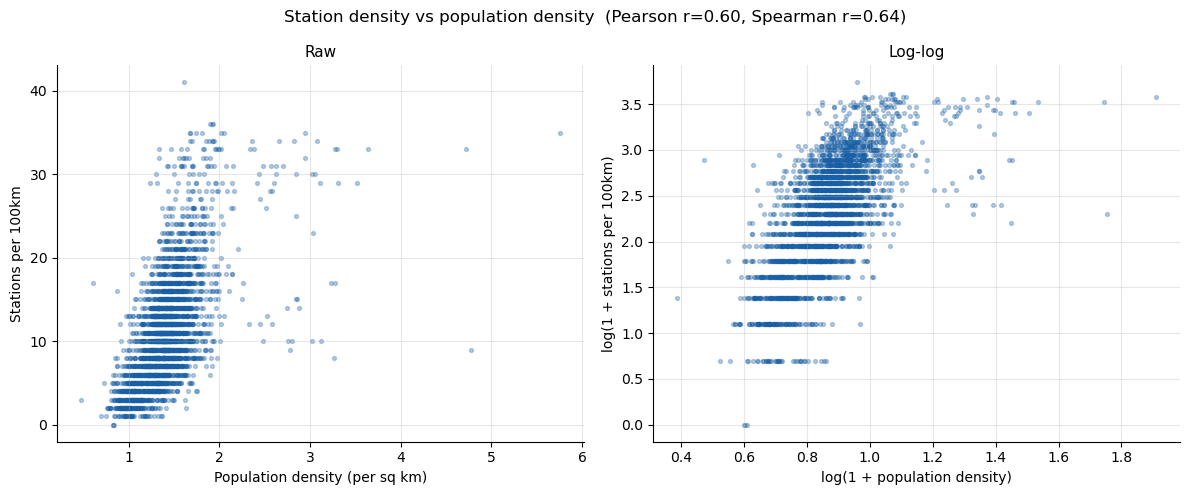

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cov = pd.read_parquet("/glade/derecho/scratch/dcalhoun/aggregated/county_covariates.parquet")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw
ax = axes[0]
ax.scatter(cov["pop_density"], cov["stations_100km"],
           alpha=0.3, s=8, color="#185FA5")
ax.set_xlabel("Population density (per sq km)", fontsize=10)
ax.set_ylabel("Stations per 100km", fontsize=10)
ax.set_title("Raw", fontsize=11)
ax.spines[["top","right"]].set_visible(False)

# Log-log
ax = axes[1]
ax.scatter(np.log1p(cov["pop_density"]), np.log1p(cov["stations_100km"]),
           alpha=0.3, s=8, color="#185FA5")
ax.set_xlabel("log(1 + population density)", fontsize=10)
ax.set_ylabel("log(1 + stations per 100km)", fontsize=10)
ax.set_title("Log-log", fontsize=11)
ax.spines[["top","right"]].set_visible(False)

for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"Station density vs population density  (Pearson r=0.60, Spearman r=0.64)",
             fontsize=12)
fig.tight_layout()
plt.show()

In [69]:
import pandas as pd
df = pd.read_parquet("/glade/derecho/scratch/dcalhoun/aggregated/regression_results_v2/bias_ifs_full_d0.parquet")
print(df[["term","coef","se_boot","pval_boot"]].to_string())

                                    term    coef  se_boot  pval_boot
0                              Intercept -0.0848   0.0234     0.0000
1   C(koppen_class, Treatment('C'))[T.A] -0.4070   0.0342     0.0000
2   C(koppen_class, Treatment('C'))[T.B]  0.1027   0.0241     0.0000
3   C(koppen_class, Treatment('C'))[T.D]  0.0275   0.0130     0.0000
4                          stations_norm -0.2445   0.0609     0.0000
5                       pop_density_norm -1.7917   0.0987     0.0000
6                          gradient_norm -0.6601   0.0388     0.0000
7                              cos_month -0.0900   0.0043     0.0000
8                              sin_month -0.5521   0.0030     0.0000
9                              lead_norm  0.0545   0.0038     0.0000
10                         valid_hour_12  0.9209   0.0036     0.0000


In [70]:
import pandas as pd
cov = pd.read_parquet("/glade/derecho/scratch/dcalhoun/aggregated/county_covariates.parquet")
print(cov.columns.tolist())

['geo_id', 'stations_100km', 'log_stations', 'elev_mean', 'elev_gradient_300km', 'koppen_class', 'pct_poverty', 'median_income', 'log_population', 'pop_density', 'pct_white', 'pct_black', 'pct_hispanic', 'pct_asian', 'pct_no_internet', 'pct_disabled', 'pct_non_english', 'pct_elderly']


In [71]:
import pandas as pd
cov = pd.read_parquet("/glade/derecho/scratch/dcalhoun/aggregated/county_covariates.parquet")
print(cov["geo_id"].dtype)
print(cov["geo_id"].head(10))

str
0    01001
1    01003
2    01005
3    01007
4    01009
5    01011
6    01013
7    01015
8    01017
9    01019
Name: geo_id, dtype: str


In [84]:
import pandas as pd

cov = pd.read_parquet("/glade/derecho/scratch/dcalhoun/aggregated/county_covariates.parquet")

division_map = {
    # New England
    "09": 1, "23": 1, "25": 1, "33": 1, "44": 1, "50": 1,
    # Middle Atlantic
    "34": 2, "36": 2, "42": 2,
    # East North Central
    "17": 3, "18": 3, "26": 3, "39": 3, "55": 3,
    # West North Central
    "19": 4, "20": 4, "27": 4, "29": 4, "31": 4, "38": 4, "46": 4,
    # South Atlantic
    "10": 5, "11": 5, "12": 5, "13": 5, "24": 5, "37": 5, "45": 5, "51": 5, "54": 5,
    # East South Central
    "01": 6, "21": 6, "28": 6, "47": 6,
    # West South Central
    "05": 7, "22": 7, "40": 7, "48": 7,
    # Mountain
    "04": 8, "08": 8, "16": 8, "30": 8, "32": 8, "35": 8, "49": 8, "56": 8,
    # Pacific
    "06": 9, "15": 9, "41": 9, "53": 9,
}

cov["division"] = cov["geo_id"].str[:2].map(division_map)
print(cov["division"].value_counts().sort_index())
print(f"\nNull divisions: {cov['division'].isna().sum()}")

division
1     68
2    150
3    437
4    618
5    588
6    364
7    470
8    281
9    133
Name: count, dtype: int64

Null divisions: 0


In [79]:
print(pd.crosstab(df["koppen_label"], df["division_name"],
                  margins=True, margins_name="Total"))

division_name  E N Central  E S Central  Mid Atlantic  Mountain  New England  \
koppen_label                                                                   
Arid                     0            0             0       170            0   
Continental            380            0           131        85           64   
Temperate               57          364            19        25            4   
Tropical                 0            0             0         0            0   
Total                  437          364           150       280           68   

division_name  Pacific  S Atlantic  W N Central  W S Central  Total  
koppen_label                                                         
Arid               104           0           53           77    404  
Continental          0          33          478            0   1171  
Temperate           29         548           87          393   1526  
Tropical             0           7            0            0      7  
Total              

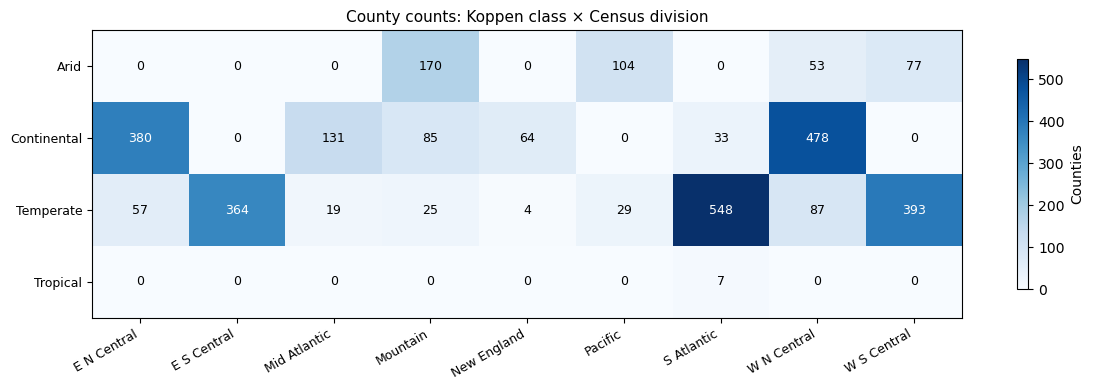

In [80]:
ct = pd.crosstab(df["koppen_label"], df["division_name"])

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(ct.values, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels(ct.index, fontsize=9)

for i in range(len(ct.index)):
    for j in range(len(ct.columns)):
        n = ct.values[i, j]
        color = "white" if n > ct.values.max() * 0.6 else "black"
        ax.text(j, i, str(n), ha="center", va="center", fontsize=9, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label="Counties")
ax.set_title("County counts: Koppen class × Census division", fontsize=11)
fig.tight_layout()
plt.show()

In [104]:
import pandas as pd
import numpy as np
from scipy import stats

cov = pd.read_parquet("/glade/derecho/scratch/dcalhoun/aggregated/county_covariates.parquet")

print("gradient_norm by division:")
print(cov.groupby("division")["gradient_norm"].describe().round(3))

for d in sorted(cov["division"].unique()):
    r, p = stats.pearsonr(
        cov.loc[cov["division"] == d, "gradient_norm"].dropna(),
        cov.loc[cov["division"] == d, "stations_norm"].dropna()
    )
    print(f"Division {d}: gradient_norm mean={cov.loc[cov['division']==d,'gradient_norm'].mean():.3f}")

gradient_norm by division:
            count    mean    std     min     25%     50%     75%    max
division                                                               
1         68.0000 -0.1010 0.0600 -0.1760 -0.1480 -0.1160 -0.0780 0.0360
2        150.0000 -0.0450 0.0810 -0.2260 -0.1080 -0.0610  0.0170 0.1480
3        437.0000  0.0130 0.0540 -0.0990 -0.0210  0.0090  0.0400 0.1660
4        618.0000 -0.1460 0.1280 -0.6570 -0.1980 -0.0950 -0.0580 0.0450
5        588.0000 -0.0960 0.1100 -0.3130 -0.1850 -0.0770 -0.0210 0.1630
6        364.0000  0.0810 0.0550 -0.0540  0.0300  0.0820  0.1260 0.1790
7        470.0000 -0.1660 0.1420 -0.5950 -0.2810 -0.1170 -0.0520 0.0260
8        281.0000 -0.0570 0.4130 -0.9180 -0.3820  0.0160  0.2660 0.7680
9        133.0000  0.3720 0.2470 -0.1790  0.2350  0.3260  0.4480 1.0000
Division 1: gradient_norm mean=-0.101
Division 2: gradient_norm mean=-0.045
Division 3: gradient_norm mean=0.013
Division 4: gradient_norm mean=-0.146
Division 5: gradient_norm mean

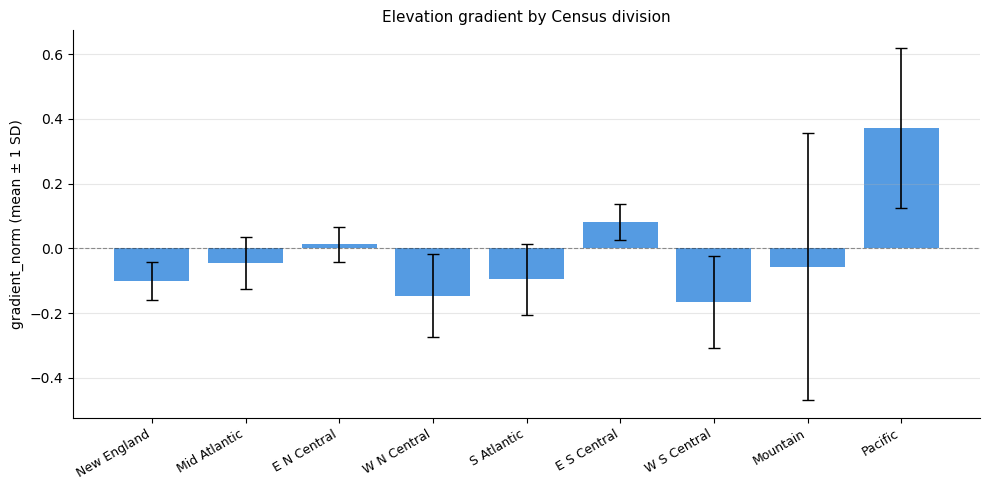

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cov = pd.read_parquet("/glade/derecho/scratch/dcalhoun/aggregated/county_covariates.parquet")

DIVISION_NAMES = {
    1: "New England", 2: "Mid Atlantic", 3: "E N Central",
    4: "W N Central", 5: "S Atlantic",   6: "E S Central",
    7: "W S Central", 8: "Mountain",     9: "Pacific",
}

div_order = sorted(cov["division"].unique())
means = [cov.loc[cov["division"] == d, "gradient_norm"].mean() for d in div_order]
sds   = [cov.loc[cov["division"] == d, "gradient_norm"].std()  for d in div_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(div_order)), means, yerr=sds, color="#378ADD", alpha=0.85,
       capsize=4, error_kw=dict(linewidth=1.2))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xticks(range(len(div_order)))
ax.set_xticklabels([DIVISION_NAMES[d] for d in div_order], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("gradient_norm (mean ± 1 SD)", fontsize=10)
ax.set_title("Elevation gradient by Census division", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

In [110]:
df

,term,coef,se_boot,ci_lower,ci_upper,pval_boot,r2,r2_adj,n_obs
0,Intercept,0.8657,0.0295,0.8080,0.9222,0.0000,0.7699,0.7699,895104
1,"C(koppen_class, Treatment('C'))[T.A]",-0.3354,0.0381,-0.4145,-0.2708,0.0000,0.7699,0.7699,895104
2,"C(koppen_class, Treatment('C'))[T.B]",0.0757,0.0150,0.0455,0.1043,0.0000,0.7699,0.7699,895104
3,"C(koppen_class, Treatment('C'))[T.D]",0.0385,0.0107,0.0195,0.0608,0.0000,0.7699,0.7699,895104
4,"C(division, Treatment(9))[T.1]",0.1434,0.0366,0.0729,0.2135,0.0000,0.7699,0.7699,895104
5,"C(division, Treatment(9))[T.2]",0.2443,0.0278,0.1906,0.2978,0.0000,0.7699,0.7699,895104
6,"C(division, Treatment(9))[T.3]",0.2880,0.0258,0.2368,0.3363,0.0000,0.7699,0.7699,895104
7,"C(division, Treatment(9))[T.4]",0.4379,0.0264,0.3852,0.4877,0.0000,0.7699,0.7699,895104
8,"C(division, Treatment(9))[T.5]",0.1470,0.0275,0.0913,0.2026,0.0000,0.7699,0.7699,895104
9,"C(division, Treatment(9))[T.6]",0.2972,0.0243,0.2539,0.3443,0.0000,0.7699,0.7699,895104


In [112]:
import pandas as pd
import os
import re

RESULTS_DIR = "/glade/derecho/scratch/dcalhoun/aggregated/regression_results_v2"

KOPPEN_NAMES = {
    "A": "Koppen Tropical (vs Temperate)",
    "B": "Koppen Arid (vs Temperate)",
    "D": "Koppen Continental (vs Temperate)",
}

DIVISION_NAMES = {
    "1": "Division New England (vs Pacific)",
    "2": "Division Mid Atlantic (vs Pacific)",
    "3": "Division E N Central (vs Pacific)",
    "4": "Division W N Central (vs Pacific)",
    "5": "Division S Atlantic (vs Pacific)",
    "6": "Division E S Central (vs Pacific)",
    "7": "Division W S Central (vs Pacific)",
    "8": "Division Mountain (vs Pacific)",
}

MONTH_NAMES = {
    "1": "Jan", "2": "Feb", "3": "Mar", "4": "Apr",
    "5": "May", "6": "Jun", "8": "Aug", "9": "Sep",
    "10": "Oct", "11": "Nov", "12": "Dec",
}

def pretty_term(t):
    # Koppen
    m = re.search(r"koppen_class.*T\.([A-Z])\]", t)
    if m:
        return KOPPEN_NAMES.get(m.group(1), t)
    # Division
    m = re.search(r"division.*T\.(\d+)\]", t)
    if m:
        return DIVISION_NAMES.get(m.group(1), t)
    # Month
    m = re.search(r"month.*T\.(\d+)\]", t)
    if m:
        return f"Month {MONTH_NAMES.get(m.group(1), m.group(1))} (vs July)"
    # Lead
    m = re.search(r"lead_time.*T\.(\d+)\]", t)
    if m:
        return f"Lead {m.group(1)}h (vs 12h)"
    # Clean up continuous terms
    rename = {
        "stations_norm":        "Station density (norm)",
        "stations_resid":       "Station density (resid | pop dens)",
        "gradient_norm":        "Elevation gradient (norm)",
        "pop_density_norm":     "Population density (norm)",
        "cos_month":            "Seasonality cos(month)",
        "sin_month":            "Seasonality sin(month)",
        "lead_norm":            "Lead time (norm)",
        "valid_hour_12":        "Valid hour 12z (vs 00z)",
        "SVI":                  "SVI (CDC overall composite)",
        "pct_poverty_prop":     "Poverty rate",
        "pct_black_prop":       "Pct Black",
        "pct_hispanic_prop":    "Pct Hispanic",
        "pct_asian_prop":       "Pct Asian",
        "pct_no_internet_prop": "Pct no internet",
        "pct_non_english_prop": "Pct non-English",
        "elderly_resid":        "Pct elderly (resid | pop dens)",
        "disabled_resid":       "Pct disabled (resid | pop dens)",
        "Intercept":            "Intercept",
    }
    return rename.get(t, t)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 130)

for domain in ["d0", "d00", "d1"]:
    for outcome in ["bias", "mae"]:
        for period in ["ifs_full", "ifs_common", "aifs_common"]:
            path = os.path.join(RESULTS_DIR, f"{outcome}_{period}_{domain}.parquet")
            if not os.path.exists(path):
                print(f"MISSING: {outcome}_{period}_{domain}")
                continue
            df = pd.read_parquet(path)
            df["term"] = df["term"].apply(pretty_term)
            print(f"\n{'='*80}")
            print(f"{domain.upper()} | {outcome.upper()} | {period} | R²={df['r2'].iloc[0]:.4f} | R²_adj={df['r2_adj'].iloc[0]:.4f} | n={df['n_obs'].iloc[0]:,}")
            print(f"{'='*80}")
            print(df[["term","coef","se_boot","ci_lower","ci_upper","pval_boot"]].to_string(index=False))


D0 | BIAS | ifs_full | R²=0.6724 | R²_adj=0.6724 | n=895,104
                              term    coef  se_boot  ci_lower  ci_upper  pval_boot
                         Intercept -0.3439   0.0364   -0.4190   -0.2758     0.0000
    Koppen Tropical (vs Temperate) -0.3260   0.0370   -0.3979   -0.2571     0.0000
        Koppen Arid (vs Temperate)  0.0699   0.0226    0.0262    0.1142     0.0000
 Koppen Continental (vs Temperate) -0.0923   0.0165   -0.1229   -0.0581     0.0000
 Division New England (vs Pacific) -0.2656   0.0418   -0.3491   -0.1883     0.0000
Division Mid Atlantic (vs Pacific) -0.5379   0.0393   -0.6131   -0.4714     0.0000
 Division E N Central (vs Pacific) -0.1045   0.0352   -0.1754   -0.0379     0.0040
 Division W N Central (vs Pacific)  0.2051   0.0368    0.1294    0.2673     0.0000
  Division S Atlantic (vs Pacific) -0.3798   0.0367   -0.4515   -0.3127     0.0000
 Division E S Central (vs Pacific) -0.3182   0.0306   -0.3806   -0.2619     0.0000
 Division W S Central (vs

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

RESULTS_DIR = "/glade/derecho/scratch/dcalhoun/aggregated/regression_results_v2"
NOTEBOOKS_DIR = "/glade/u/home/dcalhoun/nwp-census-eval/notebooks"

COLORS = {
    "ifs_full":    "#185FA5",
    "ifs_common":  "#378ADD",
    "aifs_common": "#D85A30",
}
PERIOD_LABELS = {
    "ifs_full":    "IFS full\n(2016–2025)",
    "ifs_common":  "IFS common\n(2024–2026)",
    "aifs_common": "AIFS common\n(2024–2026)",
}

def load(outcome, period, domain):
    path = os.path.join(RESULTS_DIR, f"{outcome}_{period}_{domain}.parquet")
    if not os.path.exists(path):
        return None
    return pd.read_parquet(path).set_index("term")

def get(df, term):
    if df is None or term not in df.index:
        return np.nan, np.nan
    return df.loc[term, "coef"], df.loc[term, "se_boot"]

def savefig(name):
    plt.savefig(os.path.join(NOTEBOOKS_DIR, f"{name}.pdf"), dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved {name}.pdf")

periods  = ["ifs_full", "ifs_common", "aifs_common"]
outcomes = ["bias", "mae"]

# ---------------------------------------------------------------------------
# Figure 1 — R² comparison
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Explained variance (R²) — spatiotemporal model", fontsize=13)

x = np.arange(len(periods))

for ax, outcome in zip(axes, outcomes):
    r2_vals = [load(outcome, p, "d0")["r2"].iloc[0]
               if load(outcome, p, "d0") is not None else np.nan
               for p in periods]
    ax.bar(x, r2_vals, width=0.5,
           color=[COLORS[p] for p in periods], alpha=0.85)
    for i, v in enumerate(r2_vals):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([PERIOD_LABELS[p] for p in periods], fontsize=9)
    ax.set_ylabel("R²", fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.set_title("Bias" if outcome == "bias" else "MAE", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

patches = [mpatches.Patch(color=COLORS[p], label=PERIOD_LABELS[p].replace("\n", " "))
           for p in periods]
fig.legend(handles=patches, loc="lower center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.05), frameon=False)
fig.tight_layout()
savefig("fig1_r2_comparison")

# ---------------------------------------------------------------------------
# Figure 2 — Station density coefficients
# Period colors consistent with fig 1
# Specification distinguished by solid vs hatched
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Station density effect on forecast error\n"
             "Spatiotemporal vs spatiotemporal + population density control",
             fontsize=13)

x = np.arange(len(periods))
w = 0.3

for ax, outcome in zip(axes, outcomes):
    for i, (domain, term, label, offset, hatch) in enumerate([
        ("d0",  "stations_norm",  "Spatiotemporal",               -w/2, None),
        ("d00", "stations_resid", "Spatiotemporal + pop. density",  w/2, "//"),
    ]):
        coefs, ses = [], []
        for p in periods:
            df = load(outcome, p, domain)
            c, s = get(df, term)
            coefs.append(c); ses.append(s)
        coefs = np.array(coefs); ses = np.array(ses)

        for j, p in enumerate(periods):
            ax.bar(x[j] + offset, coefs[j], width=w,
                   color=COLORS[p], alpha=0.85, hatch=hatch,
                   label=label if j == 0 else None)
            ax.errorbar(x[j] + offset, coefs[j], yerr=1.96 * ses[j],
                        fmt="none", color="black", capsize=3, linewidth=1.2)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels([PERIOD_LABELS[p] for p in periods], fontsize=9)
    ax.set_ylabel("K", fontsize=10)
    ax.set_title("Bias" if outcome == "bias" else "MAE", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

# Combined legend: period colors + specification hatching
period_patches = [mpatches.Patch(color=COLORS[p], label=PERIOD_LABELS[p].replace("\n", " "))
                  for p in periods]
spec_patches = [
    mpatches.Patch(facecolor="gray", alpha=0.85, hatch=None,  label="Spatiotemporal"),
    mpatches.Patch(facecolor="gray", alpha=0.85, hatch="//",  label="Spatiotemporal + pop. density"),
]
fig.legend(handles=period_patches + spec_patches, loc="lower center", ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.07), frameon=False)
fig.tight_layout()
savefig("fig2_station_density")

Saved fig1_r2_comparison.pdf
Saved fig2_station_density.pdf


In [144]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import os

AGGREGATED_DIR = "/glade/derecho/scratch/dcalhoun/aggregated"
NOTEBOOKS_DIR  = "/glade/u/home/dcalhoun/nwp-census-eval/notebooks"
SHP_PATH       = "/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0003_shapefile_tl2024_us_county_2024/US_county_2024.shp"

cov = pd.read_parquet(os.path.join(AGGREGATED_DIR, "county_covariates.parquet"))

gdf = gpd.read_file(SHP_PATH)
gdf = gdf.rename(columns={"GEOID": "geo_id"})
CONUS = {f"{i:02d}" for i in range(1, 57) if i not in (2, 15, 60, 64, 66, 69, 72, 74, 78)}
gdf = gdf[gdf["geo_id"].str[:2].isin(CONUS)]
gdf = gdf.merge(cov[["geo_id", "elev_mean", "elev_gradient_300km"]], on="geo_id", how="left")

AEA = "+proj=aea +lat_1=29.5 +lat_2=45.5 +lat_0=37.5 +lon_0=-96 +x_0=0 +y_0=0 +datum=NAD83 +units=m"
gdf = gdf.to_crs(AEA)
gdf["geometry"] = gdf["geometry"].simplify(1000)

xmin, ymin, xmax, ymax = gdf.total_bounds
pad = 50_000
xlim = (xmin - pad, xmax + pad)
ylim = (ymin - pad, ymax + pad)

# 300km circle — in the Gulf between the two maps, using AEA coords
# Place it in the gap at bottom center between panels
# We'll use an inset axes between the two panels

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("County-level geographic predictors — CONUS", fontsize=13, y=0.98)

# Both maps share the same xlim/ylim for alignment
ax = axes[0]
gdf.plot(column="elev_mean", ax=ax, cmap="terrain",
         vmin=0, vmax=3500, linewidth=0,
         missing_kwds={"color": "lightgray"})
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title("(a) Mean elevation", fontsize=11, pad=8)
ax.set_axis_off()
sm = plt.cm.ScalarMappable(cmap="terrain", norm=plt.Normalize(0, 3500))
sm.set_array([])
plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.02, shrink=0.8, label="m")

ax = axes[1]
vmax = gdf["elev_gradient_300km"].abs().quantile(0.98)
gdf.plot(column="elev_gradient_300km", ax=ax, cmap="RdBu_r",
         vmin=-vmax, vmax=vmax, linewidth=0,
         missing_kwds={"color": "lightgray"})
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title("(b) Elevation gradient (300km window),  negative = west higher",
             fontsize=11, pad=8)
ax.set_axis_off()
sm2 = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(-vmax, vmax))
sm2.set_array([])
plt.colorbar(sm2, ax=ax, orientation="horizontal", pad=0.02, shrink=0.8, label="m")

fig.tight_layout(rect=[0, 0, 1, 0.96])

# 300km reference circle as inset between the two panels
ax_circ = fig.add_axes([0.465, 0.3, 0.07, 0.18])
circle = Point(0, 0).buffer(300_000)
gpd.GeoSeries([circle], crs=AEA).plot(
    ax=ax_circ, facecolor="none", edgecolor="black", linewidth=1.5, linestyle="--")
ax_circ.plot(0, 0, "k+", markersize=5)
ax_circ.set_xlim(-350_000, 350_000)
ax_circ.set_ylim(-350_000, 350_000)
ax_circ.set_aspect("equal")
ax_circ.set_axis_off()
ax_circ.text(0, -400_000, "300 km", ha="center", fontsize=8, fontweight="bold")

plt.savefig(os.path.join(NOTEBOOKS_DIR, "fig_geographic_predictors.pdf"),
            dpi=300, bbox_inches="tight")
plt.close()
print("Saved fig_geographic_predictors.pdf")

Saved fig_geographic_predictors.pdf


In [145]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

AGGREGATED_DIR = "/glade/derecho/scratch/dcalhoun/aggregated"
NOTEBOOKS_DIR  = "/glade/u/home/dcalhoun/nwp-census-eval/notebooks"
SHP_PATH       = "/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0003_shapefile_tl2024_us_county_2024/US_county_2024.shp"

cov = pd.read_parquet(os.path.join(AGGREGATED_DIR, "county_covariates.parquet"))

gdf = gpd.read_file(SHP_PATH)
gdf = gdf.rename(columns={"GEOID": "geo_id"})
CONUS = {f"{i:02d}" for i in range(1, 57) if i not in (2, 15, 60, 64, 66, 69, 72, 74, 78)}
gdf = gdf[gdf["geo_id"].str[:2].isin(CONUS)]
gdf = gdf.merge(cov[["geo_id", "koppen_class"]], on="geo_id", how="left")

AEA = "+proj=aea +lat_1=29.5 +lat_2=45.5 +lat_0=37.5 +lon_0=-96 +x_0=0 +y_0=0 +datum=NAD83 +units=m"
gdf = gdf.to_crs(AEA)
gdf["geometry"] = gdf["geometry"].simplify(1000)

xmin, ymin, xmax, ymax = gdf.total_bounds
pad = 50_000
xlim = (xmin - pad, xmax + pad)
ylim = (ymin - pad, ymax + pad)

KOPPEN_COLORS = {
    "A": "#2166AC", "B": "#D6604D", "C": "#4DAF4A", "D": "#984EA3",
}
KOPPEN_LABELS = {
    "A": "A (Tropical)", "B": "B (Arid)",
    "C": "C (Temperate)", "D": "D (Continental)",
}

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for klass, color in KOPPEN_COLORS.items():
    subset = gdf[gdf["koppen_class"] == klass]
    if len(subset):
        subset.plot(ax=ax, color=color, linewidth=0)

ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title("Koppen climate class — CONUS", fontsize=12)
ax.set_axis_off()

patches = [mpatches.Patch(color=KOPPEN_COLORS[k], label=KOPPEN_LABELS[k])
           for k in ["A", "B", "C", "D"]]
ax.legend(handles=patches, loc="lower left", fontsize=9,
          frameon=True, framealpha=0.9)

fig.tight_layout()
plt.savefig(os.path.join(NOTEBOOKS_DIR, "fig_koppen.pdf"),
            dpi=300, bbox_inches="tight")
plt.close()
print("Saved fig_koppen.pdf")

Saved fig_koppen.pdf
